# 📊 Covered Call Strategy Backtesting

## 00. Import & Project Information

## Project Overview

This project focuses on **backtesting a covered call strategy** on SP500 call options using Python. The primary objective is to evaluate the performance and risk associated with this strategy.

### Objectives

1. **Testing the Strategy**: Apply the covered call strategy to historical options and price data, simulating real-market conditions.
2. **Analyzing Returns**: Examine the returns generated by the strategy over the backtesting period, comparing it to the benchmark (SP500 index).
3. **Assessing Risk**: Identify and measure the risks involved in implementing the strategy, including potential losses and volatility.

### About Covered Calls

Covered calls are popular for generating income and potentially enhancing returns in a moderately bullish or sideways market. However, they also **limit potential upside** if the underlying asset price rises significantly.

### Methodology

The backtesting process involves:

1. **Data Acquisition**: Gathering historical data on SP500 option prices and the underlying asset's price.
2. **Strategy Implementation**: Defining the rules for entering and exiting covered call positions.
3. **Performance Measurement**: Calculating key performance metrics, such as:
   - Total return
   - Sharpe ratio
   - Maximum drawdown
4. **Risk Assessment**: Evaluating risk measures, including:
   - Volatility
   - Value at Risk (VaR)
5. **Analysis and Optimization**: Analyzing the backtesting results and identifying potential areas for strategy improvement.

### Disclaimer

⚠️ **Important**: Backtesting results are hypothetical and do not guarantee future performance. Actual trading may yield different outcomes.

### Option Data Sources

- **Data Provider**: [OptionsDX](https://www.optionsdx.com/)
- **Field Definitions**: [Option Chain Field Definitions](https://www.optionsdx.com/option-chain-field-definitions/)


In [ ]:
# ============================================================================
# Import Libraries
# ============================================================================

# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical and time series analysis
from scipy import stats
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Machine learning metrics
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, RocCurveDisplay

# XGBoost for advanced modeling
import xgboost as xgb

# Yahoo Finance API for stock data retrieval
import yfinance as yf

# Google Colab integration for accessing Google Drive
from google.colab import drive

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

# Set visualization style
plt.style.use('ggplot')
sns.set_palette("husl")

In [ ]:
# Install and import pandas_ta for technical analysis indicators
!pip install pandas_ta

import pandas_ta as ta

In [ ]:
# Install and import arch library for GARCH modeling
pip install arch

from arch import arch_model

## 01. Load Data

In [ ]:
# Mount Google Drive to access data files
drive.mount('/content/drive', force_remount=True)
# !ls "/content/drive/My Drive/Colab Notebooks"

Mounted at /content/drive


### Data Files

**Note**: Each month's data is stored in a separate text file. The list below contains all files from 2010-2023.

In [ ]:
fileName = [
'spy_eod_201001.txt',
'spy_eod_201002.txt',
'spy_eod_201003.txt',
'spy_eod_201004.txt',
'spy_eod_201005.txt',
'spy_eod_201006.txt',
'spy_eod_201007.txt',
'spy_eod_201008.txt',
'spy_eod_201009.txt',
'spy_eod_201010.txt',
'spy_eod_201011.txt',
'spy_eod_201012.txt',

'spy_eod_201101.txt',
'spy_eod_201102.txt',
'spy_eod_201103.txt',
'spy_eod_201104.txt',
'spy_eod_201105.txt',
'spy_eod_201106.txt',
'spy_eod_201107.txt',
'spy_eod_201108.txt',
'spy_eod_201109.txt',
'spy_eod_201110.txt',
'spy_eod_201111.txt',
'spy_eod_201112.txt',

'spy_eod_201201.txt',
'spy_eod_201202.txt',
'spy_eod_201203.txt',
'spy_eod_201204.txt',
'spy_eod_201205.txt',
'spy_eod_201206.txt',
'spy_eod_201207.txt',
'spy_eod_201208.txt',
'spy_eod_201209.txt',
'spy_eod_201210.txt',
'spy_eod_201211.txt',
'spy_eod_201212.txt',

'spy_eod_201301.txt',
'spy_eod_201302.txt',
'spy_eod_201303.txt',
'spy_eod_201304.txt',
'spy_eod_201305.txt',
'spy_eod_201306.txt',
'spy_eod_201307.txt',
'spy_eod_201308.txt',
'spy_eod_201309.txt',
'spy_eod_201310.txt',
'spy_eod_201311.txt',
'spy_eod_201312.txt',

'spy_eod_201401.txt',
'spy_eod_201402.txt',
'spy_eod_201403.txt',
'spy_eod_201404.txt',
'spy_eod_201405.txt',
'spy_eod_201406.txt',
'spy_eod_201407.txt',
'spy_eod_201408.txt',
'spy_eod_201409.txt',
'spy_eod_201410.txt',
'spy_eod_201411.txt',
'spy_eod_201412.txt',

'spy_eod_201501.txt',
'spy_eod_201502.txt',
'spy_eod_201503.txt',
'spy_eod_201504.txt',
'spy_eod_201505.txt',
'spy_eod_201506.txt',
'spy_eod_201507.txt',
'spy_eod_201508.txt',
'spy_eod_201509.txt',
'spy_eod_201510.txt',
'spy_eod_201511.txt',
'spy_eod_201512.txt',

'spy_eod_201601.txt',
'spy_eod_201602.txt',
'spy_eod_201603.txt',
'spy_eod_201604.txt',
'spy_eod_201605.txt',
'spy_eod_201606.txt',
'spy_eod_201607.txt',
'spy_eod_201608.txt',
'spy_eod_201609.txt',
'spy_eod_201610.txt',
'spy_eod_201611.txt',
'spy_eod_201612.txt',

'spy_eod_201701.txt',
'spy_eod_201702.txt',
'spy_eod_201703.txt',
'spy_eod_201704.txt',
'spy_eod_201705.txt',
'spy_eod_201706.txt',
'spy_eod_201707.txt',
'spy_eod_201708.txt',
'spy_eod_201709.txt',
'spy_eod_201710.txt',
'spy_eod_201711.txt',
'spy_eod_201712.txt',

'spy_eod_201801.txt',
'spy_eod_201802.txt',
'spy_eod_201803.txt',
'spy_eod_201804.txt',
'spy_eod_201805.txt',
'spy_eod_201806.txt',
'spy_eod_201807.txt',
'spy_eod_201808.txt',
'spy_eod_201809.txt',
'spy_eod_201810.txt',
'spy_eod_201811.txt',
'spy_eod_201812.txt',

'spy_eod_201901.txt',
'spy_eod_201902.txt',
'spy_eod_201903.txt',
'spy_eod_201904.txt',
'spy_eod_201905.txt',
'spy_eod_201906.txt',
'spy_eod_201907.txt',
'spy_eod_201908.txt',
'spy_eod_201909.txt',
'spy_eod_201910.txt',
'spy_eod_201911.txt',
'spy_eod_201912.txt',

'spy_eod_202001.txt',
'spy_eod_202002.txt',
'spy_eod_202003.txt',
'spy_eod_202004.txt',
'spy_eod_202005.txt',
'spy_eod_202006.txt',
'spy_eod_202007.txt',
'spy_eod_202008.txt',
'spy_eod_202009.txt',
'spy_eod_202010.txt',
'spy_eod_202011.txt',
'spy_eod_202012.txt',

'spy_eod_202101.txt',
'spy_eod_202102.txt',
'spy_eod_202103.txt',
'spy_eod_202104.txt',
'spy_eod_202105.txt',
'spy_eod_202106.txt',
'spy_eod_202107.txt',
'spy_eod_202108.txt',
'spy_eod_202109.txt',
'spy_eod_202110.txt',
'spy_eod_202111.txt',
'spy_eod_202112.txt',

'spy_eod_202201.txt',
'spy_eod_202202.txt',
'spy_eod_202203.txt',
'spy_eod_202204.txt',
'spy_eod_202205.txt',
'spy_eod_202206.txt',
'spy_eod_202207.txt',
'spy_eod_202208.txt',
'spy_eod_202209.txt',
'spy_eod_202210.txt',
'spy_eod_202211.txt',
'spy_eod_202212.txt',

'spy_eod_202301.txt',
'spy_eod_202302.txt',
'spy_eod_202303.txt',
'spy_eod_202304.txt',
'spy_eod_202305.txt',
'spy_eod_202306.txt',
'spy_eod_202307.txt',
'spy_eod_202308.txt',
'spy_eod_202309.txt',
'spy_eod_202310.txt',
'spy_eod_202311.txt',
'spy_eod_202312.txt'
]

In [ ]:
# Define the path to the data files
data_path = '/content/drive/My Drive/Colab Notebooks/BPJO/'

### Load and Merge Data

**Note**: Options with `[DTE] > 15` are dropped to save memory, as we focus on near-term options.

In [ ]:
# Load first file
file_path = data_path + fileName[0]
data = pd.read_csv(file_path)

# Load and merge remaining files
for filename in fileName[1:]:
    file_path = data_path + filename
    data_up = pd.read_csv(file_path)
    
    # Filter: Keep only options with DTE <= 15 to save memory
    data_up = data_up[data_up[' [DTE]'] <= 15]
    
    # Concatenate with existing data
    data = pd.concat([data, data_up], ignore_index=True)

print(f"Total records loaded: {len(data):,}")

In [ ]:
data

,[QUOTE_UNIXTIME],[QUOTE_READTIME],[QUOTE_DATE],[QUOTE_TIME_HOURS],[UNDERLYING_LAST],[EXPIRE_DATE],[EXPIRE_UNIX],[DTE],[C_DELTA],[C_GAMMA],...,[P_LAST],[P_DELTA],[P_GAMMA],[P_VEGA],[P_THETA],[P_RHO],[P_IV],[P_VOLUME],[STRIKE_DISTANCE],[STRIKE_DISTANCE_PCT]
0,1262638800,2010-01-04 16:00,2010-01-04,16.0,113.29,2010-01-15,1263589200,11.0,0.88304,0.00005,...,0.020000,-0.00143,0.0001,0.00074,-0.00435,-0.0005,1.367420,0.000000,58.3,0.515
1,1262638800,2010-01-04 16:00,2010-01-04,16.0,113.29,2010-01-15,1263589200,11.0,0.88398,0.00005,...,0.000000,-0.0016,0.0002,0.00074,-0.00396,-0.00043,1.334760,,57.3,0.506
2,1262638800,2010-01-04 16:00,2010-01-04,16.0,113.29,2010-01-15,1263589200,11.0,0.88657,0.0,...,0.030000,-0.00146,0.00014,0.00106,-0.00369,-0.00004,1.306550,0.000000,56.3,0.497
3,1262638800,2010-01-04 16:00,2010-01-04,16.0,113.29,2010-01-15,1263589200,11.0,0.8875,0.00003,...,0.040000,-0.00166,0.00017,0.00056,-0.00428,-0.00051,1.272370,0.000000,55.3,0.488
4,1262638800,2010-01-04 16:00,2010-01-04,16.0,113.29,2010-01-15,1263589200,11.0,0.8897,0.00007,...,0.040000,-0.00167,0.00016,0.00128,-0.00429,-0.00023,1.244210,0.000000,54.3,0.479
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1880939,1703883600,2023-12-29 16:00,2023-12-29,16.0,475.31,2024-01-12,1705093200,14.0,0.00296,0.0005,...,70.08,-0.95036,0.00333,0.08723,-0.07191,-0.05247,0.303960,0.000000,49.7,0.105
1880940,1703883600,2023-12-29 16:00,2023-12-29,16.0,475.31,2024-01-12,1705093200,14.0,0.00155,0.00022,...,70.83,-0.95353,0.00255,0.07976,-0.0722,-0.0426,0.320310,0.000000,54.7,0.115
1880941,1703883600,2023-12-29 16:00,2023-12-29,16.0,475.31,2024-01-12,1705093200,14.0,0.0014,0.00021,...,0.0,-0.94997,0.00228,0.08679,-0.08639,-0.04816,0.350780,,59.7,0.126
1880942,1703883600,2023-12-29 16:00,2023-12-29,16.0,475.31,2024-01-12,1705093200,14.0,0.00061,0.00019,...,84.11,-0.94427,0.00217,0.0944,-0.10431,-0.0541,0.383790,0.000000,64.7,0.136


### Extract Price Data

In [ ]:
# Rename underlying price column for clarity
data = data.rename(columns={' [UNDERLYING_LAST]': 'Close'})

In [ ]:
print(data.columns)

Index(['[QUOTE_UNIXTIME]', ' [QUOTE_READTIME]', ' [QUOTE_DATE]',
       ' [QUOTE_TIME_HOURS]', 'Close', ' [EXPIRE_DATE]', ' [EXPIRE_UNIX]',
       ' [DTE]', ' [C_DELTA]', ' [C_GAMMA]', ' [C_VEGA]', ' [C_THETA]',
       ' [C_RHO]', ' [C_IV]', ' [C_VOLUME]', ' [C_LAST]', ' [C_SIZE]',
       ' [C_BID]', ' [C_ASK]', ' [STRIKE]', ' [P_BID]', ' [P_ASK]',
       ' [P_SIZE]', ' [P_LAST]', ' [P_DELTA]', ' [P_GAMMA]', ' [P_VEGA]',
       ' [P_THETA]', ' [P_RHO]', ' [P_IV]', ' [P_VOLUME]',
       ' [STRIKE_DISTANCE]', ' [STRIKE_DISTANCE_PCT]'],
      dtype='object')


In [ ]:
# Extract price data with timestamps
data_price = data[[' [QUOTE_READTIME]', 'Close']].copy()

In [ ]:
# Clean and prepare price data
data_price = data_price.drop_duplicates()
data_price[' [QUOTE_READTIME]'] = pd.to_datetime(data_price[' [QUOTE_READTIME]']).dt.tz_localize(None)
data_price.set_index(' [QUOTE_READTIME]', inplace=True)

In [ ]:
dataPrice

,Close
[QUOTE_READTIME],
2010-01-04 16:00:00,113.29
2010-01-05 16:00:00,113.64
2010-01-06 16:00:00,113.74
2010-01-07 16:00:00,114.20
2010-01-08 16:00:00,114.54
...,...
2023-12-22 16:00:00,473.68
2023-12-26 16:00:00,475.61
2023-12-27 16:00:00,476.47


---

## 02. Data Preparation

### Resample to Weekly Frequency

**Note**: You can switch the resampling frequency here (e.g., monthly, daily) by changing the resample period.

In [ ]:
# Resample price data to weekly frequency (end of week = Friday)
weekly_data_price = data_price.resample('W-FRI').last()

# Configuration parameters
DTE = 7  # Days to expiration for options selection
train_test_split = '2018-01-01'  # Date to split training and test sets

In [ ]:
# Ensure column name is correct (should already be 'Close' from earlier)
# weekly_data_price = weekly_data_price.rename(columns={' [UNDERLYING_LAST]': 'Close'})

In [ ]:
# Create lagged and forward-looking price features
weekly_data_price['price_lagged'] = weekly_data_price['Close'].shift(1)
weekly_data_price['price_target'] = weekly_data_price['Close'].shift(-1)

# Calculate log returns (multiplied by 100 for percentage)
weekly_data_price['log_return_lag0'] = np.log(
    weekly_data_price['Close'] / weekly_data_price['Close'].shift(1)
) * 100

# Create lagged return features
weekly_data_price['log_return_lag1'] = weekly_data_price['log_return_lag0'].shift(1)
weekly_data_price['log_return_lag2'] = weekly_data_price['log_return_lag0'].shift(2)

# Multi-period returns
weekly_data_price['log_return_lag02'] = np.log(
    weekly_data_price['Close'] / weekly_data_price['Close'].shift(2)
) * 100
weekly_data_price['log_return_lag04'] = np.log(
    weekly_data_price['Close'] / weekly_data_price['Close'].shift(4)
) * 100

# Forward-looking return (target variable)
weekly_data_price['log_return_target'] = weekly_data_price['log_return_lag0'].shift(-1)

# Cumulative returns
weekly_data_price['log_return_cumsum'] = weekly_data_price['log_return_lag0'].cumsum()

# Rolling volatility (10-week window)
weekly_data_price['log_return_rolling_std'] = weekly_data_price['log_return_lag0'].rolling(window=10).std()

In [ ]:
# Rename index to 'Date' for clarity
weekly_data_price = weekly_data_price.rename_axis('Date')

### Feature Engineering

In [ ]:
def add_ema_features(df, lengths):
    """
    Add Exponential Moving Average (EMA) features to the dataframe.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with 'Close' column
    lengths : list
        List of EMA periods to calculate
        
    Returns:
    --------
    pd.DataFrame
        DataFrame with added EMA features (normalized by Close price)
    """
    column = "Close"
    
    for length in lengths:
        column_name = f"ema_{length}"
        df[column_name] = ta.ema(df[column], length=length)
        # Normalize by current close price
        df[column_name] = df[column_name] / df["Close"]
    
    return df


def add_rsi_features(df, lengths):
    """
    Add Relative Strength Index (RSI) features to the dataframe.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with 'Close' column
    lengths : list
        List of RSI periods to calculate
        
    Returns:
    --------
    pd.DataFrame
        DataFrame with added RSI features
    """
    column = "Close"
    
    for length in lengths:
        column_name = f"rsi_{length}"
        df[column_name] = ta.rsi(df[column], length=length)
    
    return df


def add_roc_features(df, lengths):
    """
    Add Rate of Change (ROC) features to the dataframe.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with 'Close' column
    lengths : list
        List of ROC periods to calculate
        
    Returns:
    --------
    pd.DataFrame
        DataFrame with added ROC features
    """
    column = "Close"
    
    for length in lengths:
        column_name = f"roc_{length}"
        df[column_name] = ta.roc(df[column], length=length)
    
    return df


# Note: MACD can be added using:
# ta.trend.MACD(close, window_slow=26, window_fast=12, window_sign=9, fillna=False)

In [ ]:
# Define periods for technical indicators
indicator_lengths = [3, 5, 7, 15]
# Alternative longer periods: [7, 15, 30, 50, 75, 110, 200]

# Add technical indicators to weekly price data
weekly_data_price = add_ema_features(weekly_data_price, indicator_lengths)
weekly_data_price = add_rsi_features(weekly_data_price, indicator_lengths)
weekly_data_price = add_roc_features(weekly_data_price, indicator_lengths)

print("Technical indicators added successfully!")


### Prepare Options Data

Filter options data to match our analysis requirements.

In [ ]:
data

,[QUOTE_UNIXTIME],[QUOTE_READTIME],[QUOTE_DATE],[QUOTE_TIME_HOURS],Close,[EXPIRE_DATE],[EXPIRE_UNIX],[DTE],[C_DELTA],[C_GAMMA],...,[P_LAST],[P_DELTA],[P_GAMMA],[P_VEGA],[P_THETA],[P_RHO],[P_IV],[P_VOLUME],[STRIKE_DISTANCE],[STRIKE_DISTANCE_PCT]
0,1262638800,2010-01-04 16:00,2010-01-04,16.0,113.29,2010-01-15,1263589200,11.0,0.88304,0.00005,...,0.020000,-0.00143,0.0001,0.00074,-0.00435,-0.0005,1.367420,0.000000,58.3,0.515
1,1262638800,2010-01-04 16:00,2010-01-04,16.0,113.29,2010-01-15,1263589200,11.0,0.88398,0.00005,...,0.000000,-0.0016,0.0002,0.00074,-0.00396,-0.00043,1.334760,,57.3,0.506
2,1262638800,2010-01-04 16:00,2010-01-04,16.0,113.29,2010-01-15,1263589200,11.0,0.88657,0.0,...,0.030000,-0.00146,0.00014,0.00106,-0.00369,-0.00004,1.306550,0.000000,56.3,0.497
3,1262638800,2010-01-04 16:00,2010-01-04,16.0,113.29,2010-01-15,1263589200,11.0,0.8875,0.00003,...,0.040000,-0.00166,0.00017,0.00056,-0.00428,-0.00051,1.272370,0.000000,55.3,0.488
4,1262638800,2010-01-04 16:00,2010-01-04,16.0,113.29,2010-01-15,1263589200,11.0,0.8897,0.00007,...,0.040000,-0.00167,0.00016,0.00128,-0.00429,-0.00023,1.244210,0.000000,54.3,0.479
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1880939,1703883600,2023-12-29 16:00,2023-12-29,16.0,475.31,2024-01-12,1705093200,14.0,0.00296,0.0005,...,70.08,-0.95036,0.00333,0.08723,-0.07191,-0.05247,0.303960,0.000000,49.7,0.105
1880940,1703883600,2023-12-29 16:00,2023-12-29,16.0,475.31,2024-01-12,1705093200,14.0,0.00155,0.00022,...,70.83,-0.95353,0.00255,0.07976,-0.0722,-0.0426,0.320310,0.000000,54.7,0.115
1880941,1703883600,2023-12-29 16:00,2023-12-29,16.0,475.31,2024-01-12,1705093200,14.0,0.0014,0.00021,...,0.0,-0.94997,0.00228,0.08679,-0.08639,-0.04816,0.350780,,59.7,0.126
1880942,1703883600,2023-12-29 16:00,2023-12-29,16.0,475.31,2024-01-12,1705093200,14.0,0.00061,0.00019,...,84.11,-0.94427,0.00217,0.0944,-0.10431,-0.0541,0.383790,0.000000,64.7,0.136


In [ ]:
# Convert quote date to datetime
data[' [QUOTE_DATE]'] = pd.to_datetime(data[' [QUOTE_DATE]'])

# Filter options by Days To Expiration (DTE)
data = data[data[' [DTE]'] == DTE]

# Limit data to closer strike range (±7.1% from current price)
data = data[data[' [STRIKE_DISTANCE_PCT]'] < 0.0710]
data = data[data[' [STRIKE_DISTANCE_PCT]'] > -0.0710]

# Recalculate strike distance as percentage
data[' [STRIKE_DISTANCE_PCT]'] = (data[' [STRIKE]'].astype(float) / data['Close']) - 1

# Convert option prices to numeric (handle errors)
option_price_cols = [' [C_LAST]', ' [P_LAST]', ' [C_DELTA]', ' [P_DELTA]',
                     ' [C_ASK]', ' [C_BID]', ' [P_ASK]', ' [P_BID]']

for col in option_price_cols:
    data[col] = data[col].apply(pd.to_numeric, errors='coerce').fillna(0)

# Create normalized features (relative to underlying price)
data[' [C_LAST_Norm]'] = data[' [C_LAST]'].astype(float) / data["Close"]
data[' [P_LAST_Norm]'] = data[' [P_LAST]'].astype(float) / data["Close"]
data[' [C_DELTA_Norm]'] = data[' [C_DELTA]'].astype(float) / data["Close"]
data[' [P_DELTA_Norm]'] = data[' [P_DELTA]'].astype(float) / data["Close"]

# Calculate bid-ask spreads (normalized)
data['SPREAD_C'] = (data[' [C_ASK]'] - data[' [C_BID]']) / data["Close"]
data['SPREAD_P'] = (data[' [P_ASK]'] - data[' [P_BID]']) / data["Close"]
data['SPREAD_CP'] = (data[' [C_ASK]'] - data[' [P_ASK]']) / data["Close"]

print(f"Options data filtered: {len(data):,} records")

## 03. Data Exploration

In [ ]:
# Prepare data for plotting (from 2011 onwards)
weekly_data_price_plot = weekly_data_price[weekly_data_price.index >= '2011-01-01'].copy()
weekly_data_price_plot['log_return_cumsum'] = weekly_data_price_plot['log_return_lag0'].cumsum()

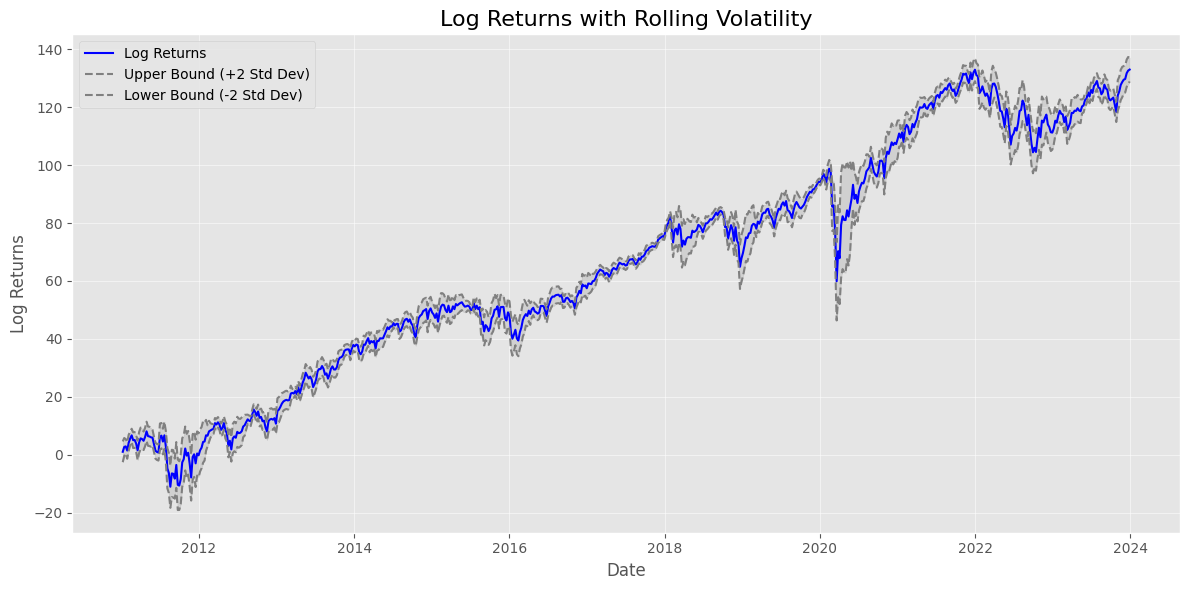

In [ ]:
# Plot cumulative log returns with volatility bands
plt.figure(figsize=(14, 7))

# Calculate volatility bands
upper_band = weekly_data_price_plot['log_return_cumsum'] + \
             weekly_data_price_plot['log_return_rolling_std'] * 2
lower_band = weekly_data_price_plot['log_return_cumsum'] - \
             weekly_data_price_plot['log_return_rolling_std'] * 2

# Plot cumulative returns
plt.plot(weekly_data_price_plot['log_return_cumsum'], 
         label='Cumulative Log Returns', 
         color='#2E86AB', 
         linewidth=2)

# Plot volatility bands
plt.plot(upper_band, 
         label='Upper Bound (+2 Std Dev)', 
         color='gray', 
         linestyle='--', 
         alpha=0.7)
plt.plot(lower_band, 
         label='Lower Bound (-2 Std Dev)', 
         color='gray', 
         linestyle='--', 
         alpha=0.7)

# Add shaded confidence interval
plt.fill_between(weekly_data_price_plot.index,
                 upper_band,
                 lower_band,
                 color='gray', 
                 alpha=0.15,
                 label='±2 Std Dev Band')

# Enhance plot aesthetics
plt.title('Cumulative Log Returns with Rolling Volatility Bands', 
          fontsize=16, 
          fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Log Returns (%)', fontsize=12)
plt.legend(loc='best', fontsize=10, frameon=True, shadow=True)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

plt.show()

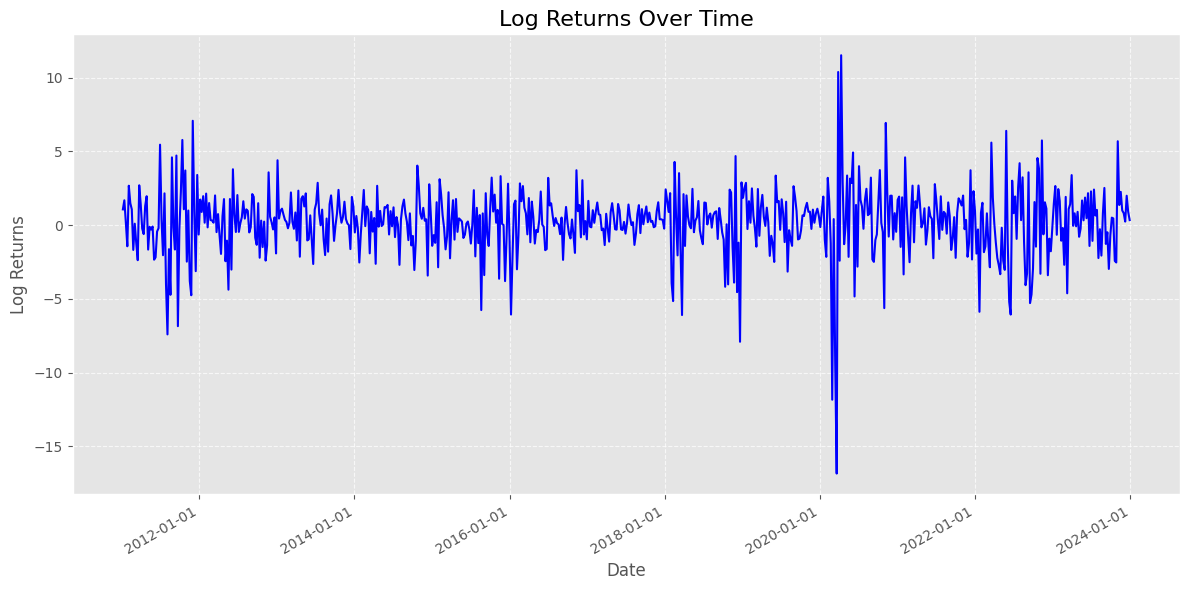

In [ ]:
import matplotlib.dates as mdates

# Plot weekly log returns over time
plt.figure(figsize=(14, 6))

plt.plot(weekly_data_price_plot.index, 
         weekly_data_price_plot['log_return_lag0'],
         color='#2E86AB', 
         linewidth=1.5, 
         linestyle='-',
         alpha=0.8)

# Customize the plot
plt.title('Weekly Log Returns Over Time', 
          fontsize=16, 
          fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Log Returns (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)

# Format the x-axis dates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

### Summary Statistics

In [ ]:
# Extract log returns and remove NaN values
log_returns = weekly_data_price_plot['log_return_lag0'].dropna()

# Calculate summary statistics
mean = log_returns.mean()
std_dev = log_returns.std()
skewness = log_returns.skew()
kurtosis = log_returns.kurtosis()

# Display formatted statistics
print("=" * 50)
print("Summary Statistics for Weekly Log Returns")
print("=" * 50)
print(f"Mean:              {mean:>10.4f} %")
print(f"Standard Deviation: {std_dev:>10.4f} %")
print(f"Skewness:          {skewness:>10.4f}")
print(f"Kurtosis:          {kurtosis:>10.4f}")
print("=" * 50)

Mean: 0.19608154478272208
Standard Deviation: 2.273735933558178
Skewness: -0.8790513949558423
Kurtosis: 7.637930607639022


### Distribution Analysis

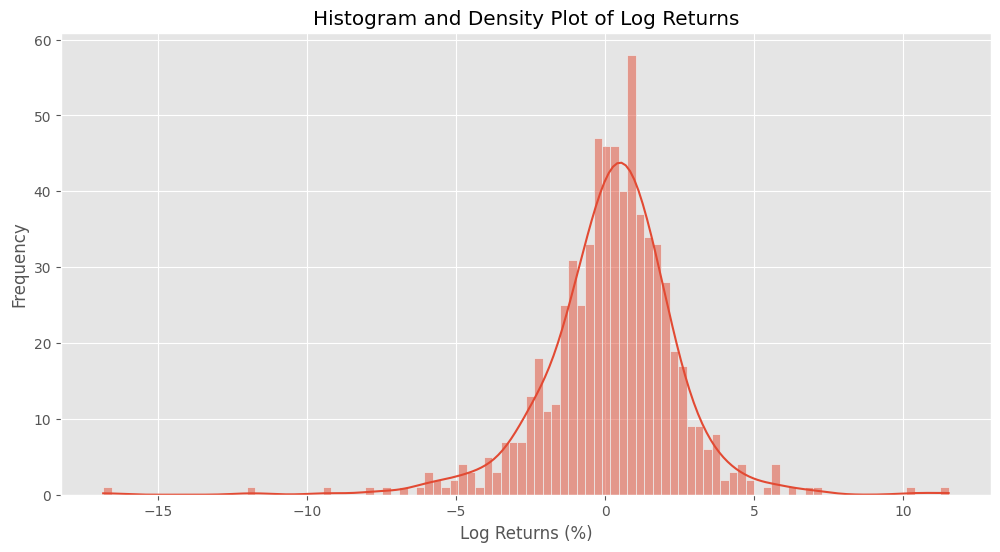

In [ ]:
# Create histogram with density plot
plt.figure(figsize=(12, 6))
sns.histplot(log_returns, 
             bins=100, 
             kde=True,
             color='#2E86AB',
             alpha=0.7,
             edgecolor='black',
             linewidth=0.5)

plt.title('Distribution of Weekly Log Returns', 
          fontsize=16, 
          fontweight='bold')
plt.xlabel('Log Returns (%)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--', axis='y')
plt.tight_layout()
plt.show()


### Autocorrelation Analysis

<Figure size 1200x600 with 0 Axes>

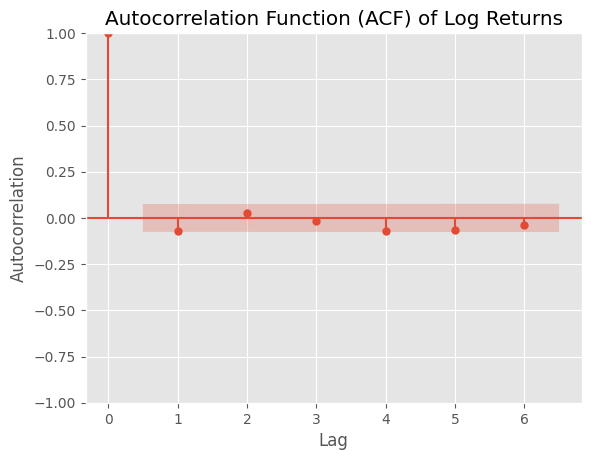

<Figure size 1200x600 with 0 Axes>

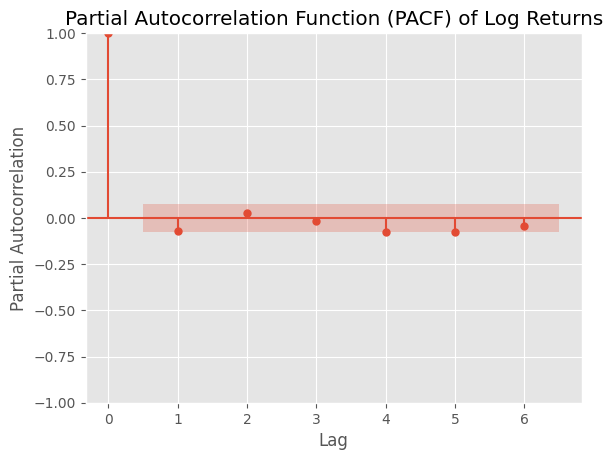

In [ ]:
# Plot Autocorrelation Function (ACF)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ACF Plot
sm.graphics.tsa.plot_acf(log_returns, lags=6, ax=axes[0], 
                        color='#2E86AB', alpha=0.7)
axes[0].set_title('Autocorrelation Function (ACF)', 
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Lag', fontsize=11)
axes[0].set_ylabel('Autocorrelation', fontsize=11)
axes[0].grid(True, alpha=0.3, linestyle='--')

# PACF Plot
sm.graphics.tsa.plot_pacf(log_returns, lags=6, ax=axes[1],
                         color='#A23B72', alpha=0.7)
axes[1].set_title('Partial Autocorrelation Function (PACF)', 
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Lag', fontsize=11)
axes[1].set_ylabel('Partial Autocorrelation', fontsize=11)
axes[1].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


### Normality Tests

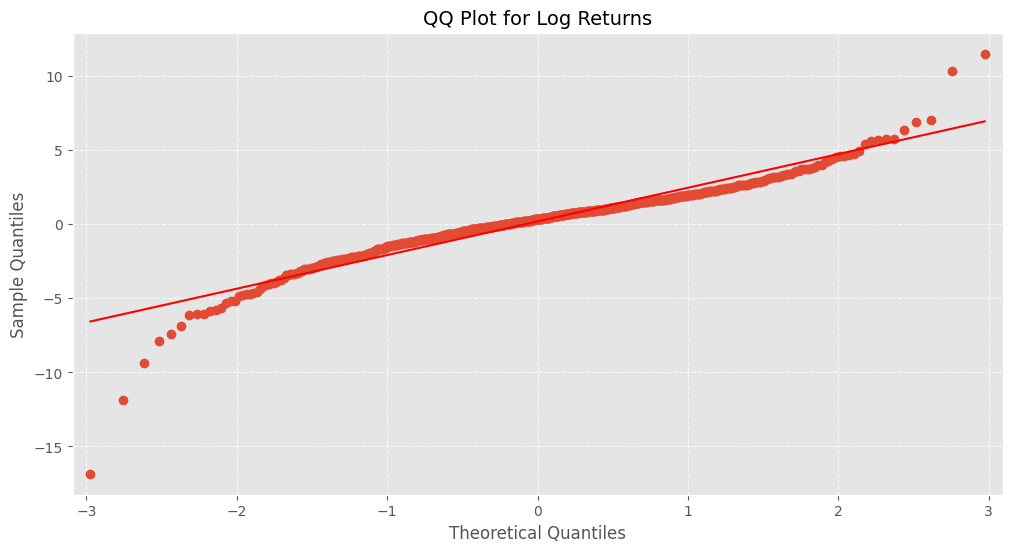

Shapiro-Wilk Test Results:
  Statistic: 0.9211
  P-value:   0.0000

The data does not appear to be normally distributed (p-value < 0.05).


In [ ]:
# Q-Q Plot for normality assessment
fig, ax = plt.subplots(figsize=(10, 6))
sm.qqplot(log_returns, line='s', ax=ax, color='#2E86AB', alpha=0.7)

ax.set_title('Q-Q Plot: Log Returns vs Normal Distribution', 
             fontsize=14, 
             fontweight='bold')
ax.set_xlabel('Theoretical Quantiles (Normal)', fontsize=12)
ax.set_ylabel('Sample Quantiles (Log Returns)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Shapiro-Wilk Normality Test
shapiro_test = stats.shapiro(log_returns)
alpha = 0.05

print("\n" + "=" * 50)
print("Shapiro-Wilk Normality Test Results")
print("=" * 50)
print(f"Test Statistic: {shapiro_test.statistic:.4f}")
print(f"P-value:        {shapiro_test.pvalue:.6f}")
print(f"Significance:   α = {alpha}")

if shapiro_test.pvalue < alpha:
    print(f"\n✓ Reject H₀: Data does NOT follow a normal distribution")
    print(f"  (p-value < {alpha})")
else:
    print(f"\n✗ Fail to reject H₀: Data appears normally distributed")
    print(f"  (p-value ≥ {alpha})")
print("=" * 50)

**Note**: For normality, we typically require p-value > 0.05. Lower p-values indicate non-normal distributions.

## 04. Econometric Estimation

### GARCH Model for Volatility Forecasting

In [ ]:
# Prepare data for GARCH modeling (need extra month for initialization)
weekly_data_price_garch = weekly_data_price[weekly_data_price.index >= '2010-12-01'].copy()
log_returns_garch = weekly_data_price_garch['log_return_lag0']

# Update main dataset to start from end of 2010
weekly_data_price = weekly_data_price[weekly_data_price.index >= '2010-12-31']

#### GARCH Model Specification

In [ ]:
def calculate_value_at_risk(cond_mean, cond_var, quantiles):
    """
    Calculate Value at Risk (VaR) from GARCH conditional mean and variance.
    
    Parameters:
    -----------
    cond_mean : pd.Series
        Conditional mean from GARCH model
    cond_var : pd.Series
        Conditional variance from GARCH model
    quantiles : array-like
        Quantile values (e.g., [0.01, 0.05, 0.20] for 1%, 5%, 20% VaR)
        
    Returns:
    --------
    pd.DataFrame
        DataFrame with VaR values for each quantile level
    """
    value_at_risk = -cond_mean.values - np.sqrt(cond_var).values * quantiles[None, :]
    value_at_risk = pd.DataFrame(value_at_risk, 
                                columns=["1%", "5%", "20%"], 
                                index=cond_var.index)
    return value_at_risk

In [ ]:
# Grid search for optimal GARCH(p,q) parameters
p_values = range(1, 6)
q_values = range(1, 6)

# Initialize variables to store best model
best_p = None
best_q = None
best_aic = np.inf

print("Searching for optimal GARCH parameters...")
print("-" * 50)

# Loop over all combinations of p and q
for p in p_values:
    for q in q_values:
        try:
            # Estimate GARCH model with current parameters
            am = arch_model(log_returns_garch, 
                          vol="Garch", 
                          p=p, 
                          o=0, 
                          q=q, 
                          dist="skewt")
            res = am.fit(disp="off", last_obs=train_test_split)

            # Update best model if AIC is lower
            if res.aic < best_aic:
                best_p, best_q = p, q
                best_aic = res.aic
                print(f"  New best: GARCH({p},{q}) - AIC: {best_aic:.2f}")
        except Exception as e:
            # Skip models that fail to converge
            continue

print("-" * 50)
print(f"\n✓ Optimal GARCH model: GARCH({best_p},{best_q})")
print(f"  AIC: {best_aic:.4f}")


Optimal values found: p = 1, q = 1 with AIC = 1401.1058944600245


In [ ]:
# Fit optimal GARCH model
p = best_p
q = best_q

am = arch_model(log_returns_garch, 
                vol="Garch", 
                p=p, 
                o=0, 
                q=q, 
                dist="skewt")
res = am.fit(disp="off", last_obs=train_test_split)

# Calculate quantiles for VaR (1%, 5%, 20%)
quantiles = am.distribution.ppf([0.01, 0.05, 0.2], res.params[-2:])
print(f"\nVaR Quantiles calculated: {quantiles}")


In [ ]:
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Constant Mean - GARCH Model Results                           
=========================================================================================
Dep. Variable:                     logReturnLag0   R-squared:                       0.000
Mean Model:                        Constant Mean   Adj. R-squared:                  0.000
Vol Model:                                 GARCH   Log-Likelihood:               -694.553
Distribution:      Standardized Skew Student's t   AIC:                           1401.11
Method:                       Maximum Likelihood   BIC:                           1424.59
                                                   No. Observations:                  370
Date:                           Wed, Nov 13 2024   Df Residuals:                      369
Time:                                   00:28:33   Df Model:                            1
                               Mean Model                               
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0.2624  7.911e-02      3.317  9.115e-04 [  0.107,  0.417]
                              Volatility Model                             
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          0.1395      0.191      0.730      0.465    [ -0.235,  0.514]
alpha[1]       0.1678  9.550e-02      1.757  7.890e-02 [-1.938e-02,  0.355]
beta[1]        0.7908      0.146      5.415  6.132e-08    [  0.505,  1.077]
                                Distribution                               
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
eta            7.6671      2.978      2.575  1.004e-02    [  1.830, 13.504]
lambda        -0.1562  6.554e-02     -2.384  1.712e-02 [ -0.285,-2.779e-02]
===========================================================================

Covariance estimator: robust
"""

#### Calculate Value at Risk (VaR)

In [ ]:
# Generate GARCH forecasts
forecasts = res.forecast(start='2010-01-01', reindex=False, align="target")

# Extract conditional mean and variance
cond_mean = forecasts.mean.dropna()
cond_var = forecasts.variance.dropna()

# Calculate Value at Risk
value_at_risk_df = calculate_value_at_risk(cond_mean, cond_var, quantiles)

print(f"VaR calculated for {len(value_at_risk_df)} periods")

In [ ]:
# Merge VaR forecasts into main dataframe
weekly_data_price["GARCH11_1"] = value_at_risk_df["1%"]
weekly_data_price["GARCH11_5"] = value_at_risk_df["5%"]
weekly_data_price["GARCH11_20"] = value_at_risk_df["20%"]

print("VaR forecasts merged into weekly_data_price")

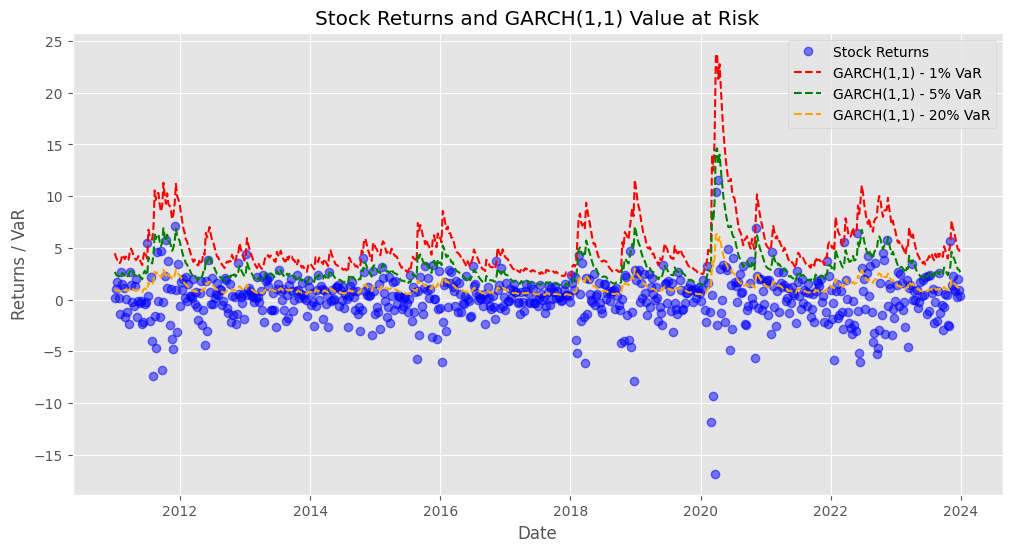

In [ ]:
# Visualize GARCH VaR forecasts
plt.figure(figsize=(14, 7))

# Plot underlying stock returns
plt.plot(weekly_data_price['log_return_lag0'], 
         label='Stock Returns', 
         color='#2E86AB', 
         marker='o', 
         linestyle='', 
         alpha=0.4,
         markersize=3)

# Plot GARCH VaR lines
plt.plot(weekly_data_price['GARCH11_1'], 
         label='GARCH(1,1) - 1% VaR', 
         color='#D62828', 
         linestyle='--',
         linewidth=1.5)
plt.plot(weekly_data_price['GARCH11_5'], 
         label='GARCH(1,1) - 5% VaR', 
         color='#06A77D', 
         linestyle='--',
         linewidth=1.5)
plt.plot(weekly_data_price['GARCH11_20'], 
         label='GARCH(1,1) - 20% VaR', 
         color='#F77F00', 
         linestyle='--',
         linewidth=1.5)

# Enhance plot
plt.title('Stock Returns and GARCH(1,1) Value at Risk Forecasts', 
          fontsize=16, 
          fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Returns / VaR (%)', fontsize=12)
plt.legend(loc='best', fontsize=10, frameon=True, shadow=True)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

## 05. Machine Learning Estimation

In [ ]:
# Merge options data with weekly price features
data_extended = pd.merge(data, weekly_data_price, on='Close', how='inner')

# Create target variable: In-The-Money (ITM) indicator
# ITM = 1 if strike < target price at expiration, else 0
data_extended["ITM"] = (data_extended[' [STRIKE]'] < data_extended["price_target"]).astype(int)

print(f"Merged dataset: {len(data_extended):,} records")
print(f"ITM rate: {data_extended['ITM'].mean():.2%}")

In [ ]:
def clean_column_name(col):
    """Clean column names by removing brackets, angle brackets, and spaces."""
    return col.replace('[', '').replace(']', '').replace('<', '').replace(' ', '')

# Clean all column names for easier access
data_extended = data_extended.rename(columns=clean_column_name)
print("Column names cleaned")

### Feature Selection and Model Metrics

In [ ]:
dataExtended.columns

Index(['QUOTE_UNIXTIME', 'QUOTE_READTIME', 'QUOTE_DATE', 'QUOTE_TIME_HOURS',
       'Close', 'EXPIRE_DATE', 'EXPIRE_UNIX', 'DTE', 'C_DELTA', 'C_GAMMA',
       'C_VEGA', 'C_THETA', 'C_RHO', 'C_IV', 'C_VOLUME', 'C_LAST', 'C_SIZE',
       'C_BID', 'C_ASK', 'STRIKE', 'P_BID', 'P_ASK', 'P_SIZE', 'P_LAST',
       'P_DELTA', 'P_GAMMA', 'P_VEGA', 'P_THETA', 'P_RHO', 'P_IV', 'P_VOLUME',
       'STRIKE_DISTANCE', 'STRIKE_DISTANCE_PCT', 'C_LAST_Norm', 'P_LAST_Norm',
       'C_DELTA_Norm', 'P_DELTA_Norm', 'SPREAD_C', 'SPREAD_P', 'SPREAD_CP',
       'priceLaged', 'priceTarget', 'logReturnLag0', 'logReturnLag1',
       'logReturnLag2', 'logReturnLag02', 'logReturnLag04', 'logReturnTarget',
       'logReturnSum', 'logReturnRollingStd', 'ema_3', 'ema_5', 'ema_7',
       'ema_15', 'rsi_3', 'rsi_5', 'rsi_7', 'rsi_15', 'roc_3', 'roc_5',
       'roc_7', 'roc_15', 'GARCH11_1', 'GARCH11_5', 'GARCH11_20', 'ITM'],
      dtype='object')

In [ ]:
# Remove infinite values
data_extended = data_extended[~data_extended.isin([np.inf, -np.inf]).any(axis=1)]

# Split data into training and test sets based on date
train_data = data_extended[data_extended['QUOTE_DATE'] < train_test_split].copy()
test_data = data_extended[data_extended['QUOTE_DATE'] >= train_test_split].copy()

# Ensure all columns (except QUOTE_DATE) are numeric and fill NaN with 0
numeric_cols = train_data.columns.difference(['QUOTE_DATE'])

for col in numeric_cols:
    train_data[col] = pd.to_numeric(train_data[col], errors='coerce').fillna(0)
    test_data[col] = pd.to_numeric(test_data[col], errors='coerce').fillna(0)

# Define feature set
features = [
    # Option Greeks
    'C_GAMMA', 'C_VEGA', 'C_THETA', 'C_RHO', 'C_IV',
    'P_GAMMA', 'P_VEGA', 'P_THETA', 'P_RHO', 'P_IV',
    
    # Normalized option prices and deltas
    'P_LAST_Norm', 'C_LAST_Norm', 'P_DELTA_Norm', 'C_DELTA_Norm',
    
    # Strike information
    'STRIKE_DISTANCE_PCT',
    
    # Return features
    'logReturnLag0', 'logReturnLag1', 'logReturnLag2', 
    'logReturnLag02', 'logReturnLag04', 'logReturnRollingStd',
    
    # Technical indicators
    'ema_5', 'ema_7', 'rsi_5', 'rsi_7',
    
    # Bid-ask spreads
    'SPREAD_C', 'SPREAD_P', 'SPREAD_CP'
]

# Prepare feature matrices and target vectors
X_train = train_data[features].astype(float)
y_train = train_data['ITM']

X_test = test_data[features].astype(float)
y_test = test_data['ITM']

print(f"Training set: {len(X_train):,} samples")
print(f"Test set:     {len(X_test):,} samples")
print(f"Features:     {len(features)}")

In [ ]:
def evaluate_model_metrics(model, X_train, X_test, y_train, y_test, model_name="Model"):
    """
    Evaluate model performance and create visualization plots.
    
    Parameters:
    -----------
    model : sklearn model
        Trained model with predict and predict_proba methods
    X_train, X_test : pd.DataFrame
        Feature matrices
    y_train, y_test : pd.Series
        Target vectors
    model_name : str
        Name of the model for display purposes
    """
    # Training set predictions
    y_pred_train = model.predict(X_train)
    y_proba_train = model.predict_proba(X_train)[:, 1]
    
    # Test set predictions
    y_pred_test = model.predict(X_test)
    y_proba_test = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    accuracy_train = accuracy_score(y_train, y_pred_train)
    roc_auc_train = roc_auc_score(y_train, y_proba_train)
    accuracy_test = accuracy_score(y_test, y_pred_test)
    roc_auc_test = roc_auc_score(y_test, y_proba_test)
    
    # Print metrics
    print("=" * 70)
    print(f"Model Performance Metrics: {model_name}")
    print("=" * 70)
    print(f"{'Metric':<20} {'Training':<15} {'Test':<15}")
    print("-" * 70)
    print(f"{'Accuracy':<20} {accuracy_train:<15.4f} {accuracy_test:<15.4f}")
    print(f"{'ROC AUC':<20} {roc_auc_train:<15.4f} {roc_auc_test:<15.4f}")
    print("=" * 70)
    
    # Plot ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_proba_test)
    
    plt.figure(figsize=(10, 6))
    plt.plot(fpr, tpr, 
             label=f'ROC curve (AUC = {roc_auc_test:.4f})', 
             color='#2E86AB', 
             linewidth=2)
    plt.plot([0, 1], [0, 1], 
             'k--', 
             label='Random Classifier', 
             linewidth=1.5,
             alpha=0.7)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'ROC Curve: {model_name}', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=10, frameon=True, shadow=True)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Feature Importance (if available)
    if hasattr(model, 'feature_importances_'):
        importance = model.feature_importances_
        importance_df = pd.DataFrame({
            'Feature': X_train.columns, 
            'Importance': importance
        }).sort_values(by='Importance', ascending=False)
        
        # Plot top 15 features
        top_features = importance_df.head(15)
        
        plt.figure(figsize=(10, 8))
        plt.barh(top_features['Feature'], 
                top_features['Importance'], 
                color='#2E86AB',
                alpha=0.8)
        plt.xlabel('Importance', fontsize=12)
        plt.title(f'Top 15 Feature Importance: {model_name}', 
                 fontsize=14, 
                 fontweight='bold')
        plt.gca().invert_yaxis()
        plt.grid(True, alpha=0.3, linestyle='--', axis='x')
        plt.tight_layout()
        plt.show()
    
    return {
        'accuracy_train': accuracy_train,
        'roc_auc_train': roc_auc_train,
        'accuracy_test': accuracy_test,
        'roc_auc_test': roc_auc_test
    }

### Random Forest Classifier

**Random Forest** is an ensemble learning method that combines multiple decision trees to improve prediction accuracy. By averaging the results of several trees, it reduces overfitting and increases robustness. 

**Key Advantages:**
- Versatile: handles both classification and regression tasks
- Robust to noisy data and missing values
- Provides feature importance insights
- Reduces overfitting through ensemble averaging

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest model
model_rf = RandomForestClassifier(
    n_estimators=30,           # Number of trees in the forest
    max_depth=4,               # Maximum depth of trees
    min_samples_split=20,      # Minimum samples to split a node
    min_samples_leaf=20,       # Minimum samples at a leaf node
    max_features='sqrt',       # Features to consider for best split
    random_state=42            # Seed for reproducibility
)

# Train the model
print("Training Random Forest model...")
model_rf.fit(X_train, y_train)
print("✓ Training complete!")

# Make predictions on test set
y_test_pred_rf = model_rf.predict(X_test)
y_test_proba_rf = model_rf.predict_proba(X_test)[:, 1]

Model Metrices
Accuracy Train: 0.9135
ROC AUC  Train: 0.9738
Accuracy  Test: 0.8712
ROC AUC   Test: 0.9460
--------------------------------------------------------------------------------------------


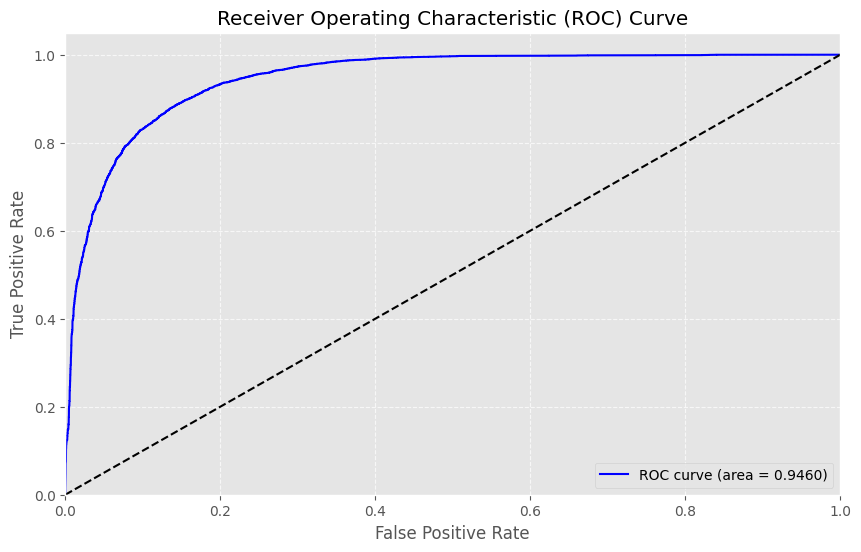

--------------------------------------------------------------------------------------------


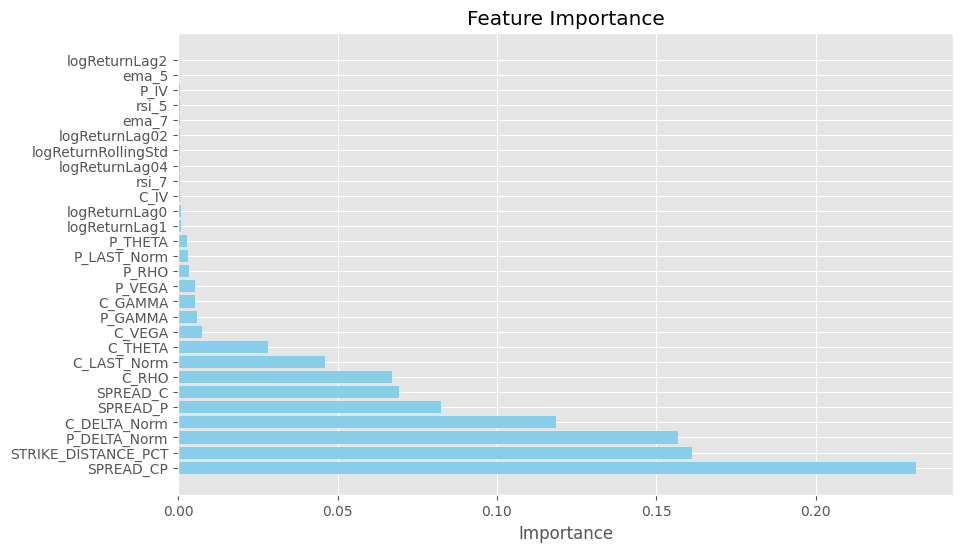

0

In [ ]:
# Evaluate Random Forest model
evaluate_model_metrics(model_rf, X_train, X_test, y_train, y_test, "Random Forest")

### XGBoost Classifier

**XGBoost** (Extreme Gradient Boosting) is a powerful machine learning algorithm that builds an ensemble of decision trees using gradient boosting. It optimizes both model performance and computational efficiency.

**Key Features:**
- Gradient boosting framework for sequential tree building
- Regularization techniques to prevent overfitting
- High performance and scalability
- Widely used in competitions and production systems
- Handles missing values and feature interactions well

In [ ]:
# Initialize XGBoost model
model_xgb = xgb.XGBClassifier(
    objective='binary:logistic',  # Binary classification
    n_estimators=300,              # Number of boosting rounds
    learning_rate=0.01,            # Step size shrinkage
    max_depth=3,                   # Maximum tree depth
    subsample=0.8,                 # Row subsampling ratio
    colsample_bytree=0.8,          # Column subsampling ratio
    gamma=0.1,                     # Minimum loss reduction
    reg_alpha=0.1,                 # L1 regularization
    reg_lambda=1.0,                # L2 regularization
    random_state=42                # Seed for reproducibility
)

# Train the model with evaluation sets
print("Training XGBoost model...")
model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=True
)
print("✓ Training complete!")

[0]	validation_0-logloss:0.67875	validation_1-logloss:0.68845
[1]	validation_0-logloss:0.67164	validation_1-logloss:0.68212
[2]	validation_0-logloss:0.66467	validation_1-logloss:0.67576
[3]	validation_0-logloss:0.65785	validation_1-logloss:0.66963
[4]	validation_0-logloss:0.65117	validation_1-logloss:0.66362
[5]	validation_0-logloss:0.64460	validation_1-logloss:0.65786
[6]	validation_0-logloss:0.63817	validation_1-logloss:0.65204
[7]	validation_0-logloss:0.63187	validation_1-logloss:0.64681
[8]	validation_0-logloss:0.62566	validation_1-logloss:0.64126
[9]	validation_0-logloss:0.61958	validation_1-logloss:0.63603
[10]	validation_0-logloss:0.61360	validation_1-logloss:0.63071
[11]	validation_0-logloss:0.60773	validation_1-logloss:0.62542
[12]	validation_0-logloss:0.60200	validation_1-logloss:0.62046
[13]	validation_0-logloss:0.59636	validation_1-logloss:0.61522
[14]	validation_0-logloss:0.59082	validation_1-logloss:0.61058
[15]	validation_0-logloss:0.58539	validation_1-logloss:0.60574
[1

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.1, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

Model Metrices
Accuracy Train: 0.9146
ROC AUC  Train: 0.9750
Accuracy  Test: 0.8720
ROC AUC   Test: 0.9490
--------------------------------------------------------------------------------------------


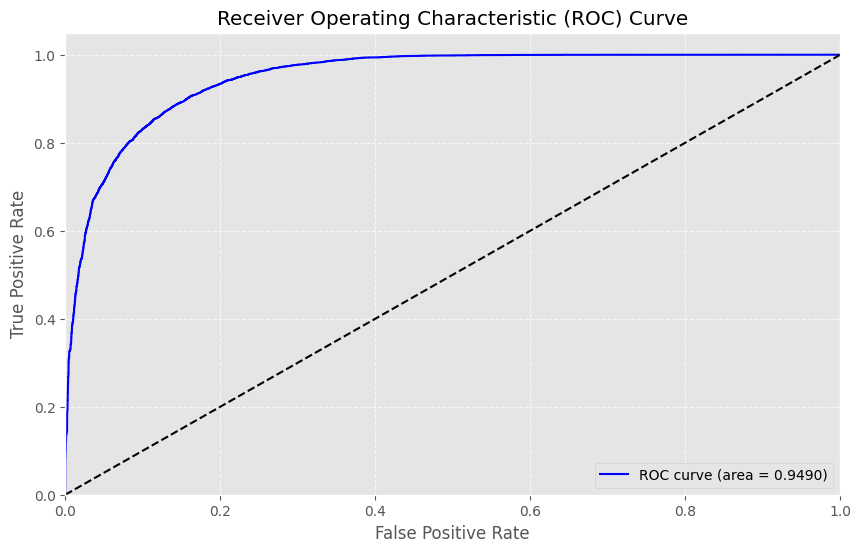

--------------------------------------------------------------------------------------------


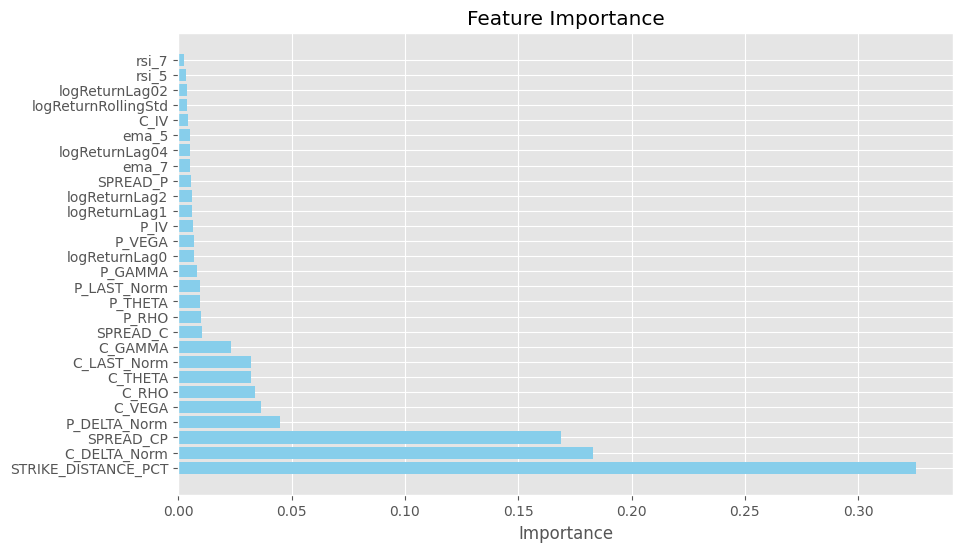

0

In [ ]:
# Evaluate XGBoost model
evaluate_model_metrics(model_xgb, X_train, X_test, y_train, y_test, "XGBoost")

### Model Probability Analysis

In [ ]:
# Get XGBoost predictions and probabilities
y_pred_xgb = model_xgb.predict(X_test)
y_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]

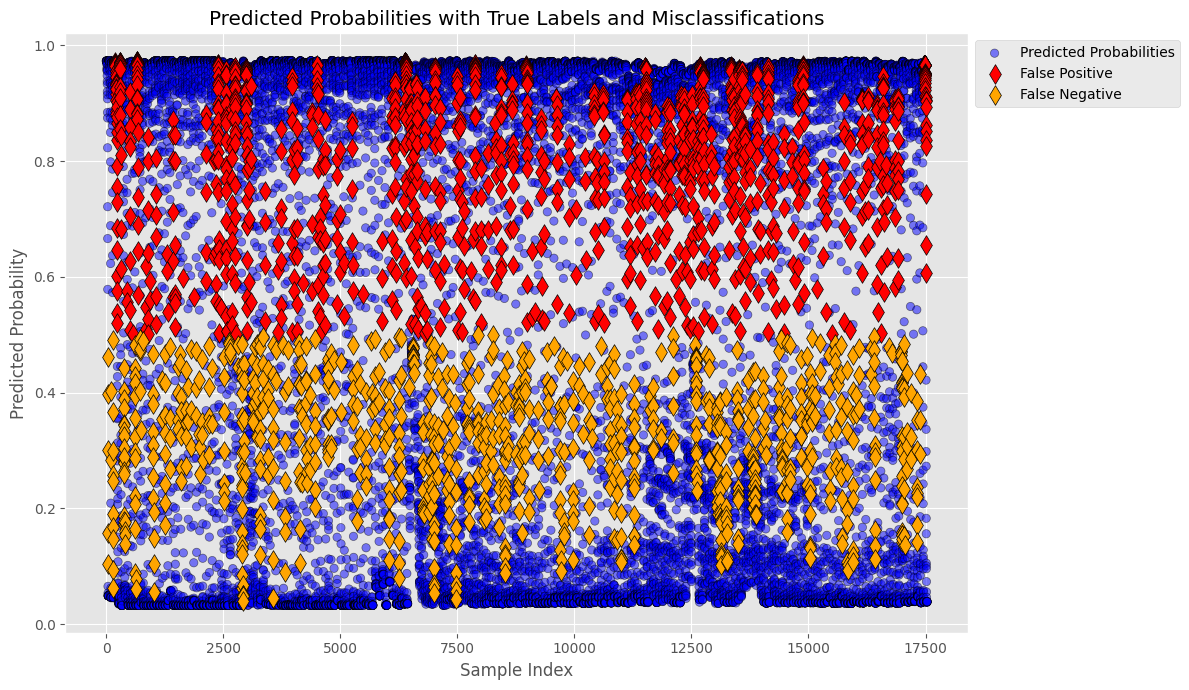

In [ ]:
# Visualize predicted probabilities with misclassifications
plt.figure(figsize=(14, 7))

# Calculate predictions with 0.5 threshold
y_pred_thresh = (y_proba_xgb >= 0.5).astype(int)

# Identify misclassifications
fp_indices = np.where((y_test == 0) & (y_pred_thresh == 1))[0]  # False Positives
fn_indices = np.where((y_test == 1) & (y_pred_thresh == 0))[0]  # False Negatives

# Plot all probabilities
plt.scatter(range(len(y_proba_xgb)), 
           y_proba_xgb, 
           c='#2E86AB', 
           alpha=0.4, 
           s=20,
           edgecolor='none',
           label='Predicted Probabilities')

# Highlight misclassifications
if len(fp_indices) > 0:
    plt.scatter(fp_indices, 
               y_proba_xgb[fp_indices], 
               marker='X', 
               color='#D62828', 
               label='False Positive', 
               s=80, 
               edgecolor='black',
               linewidth=1,
               zorder=5)

if len(fn_indices) > 0:
    plt.scatter(fn_indices, 
               y_proba_xgb[fn_indices], 
               marker='X', 
               color='#F77F00', 
               label='False Negative', 
               s=80, 
               edgecolor='black',
               linewidth=1,
               zorder=5)

# Add threshold line
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='Decision Threshold (0.5)')

# Enhance plot
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Predicted Probability', fontsize=12)
plt.title('XGBoost Predicted Probabilities with Misclassifications', 
          fontsize=14, 
          fontweight='bold')
plt.legend(loc='upper left', fontsize=10, frameon=True, shadow=True)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print(f"False Positives: {len(fp_indices):,} ({len(fp_indices)/len(y_test)*100:.2f}%)")
print(f"False Negatives: {len(fn_indices):,} ({len(fn_indices)/len(y_test)*100:.2f}%)")


In [ ]:
# Combine training and test data for expectancy calculations
data_extended_res = pd.concat([train_data, test_data], ignore_index=True)

## 06. Option Expectancy Calculation


Option expectancy refers to the expected value of an option's payoff, considering both the probability of the option finishing in-the-money and the magnitude of that payoff. In this code, the ExpectancyMLMod_FCE function computes the option expectancy by predicting the likelihood of an option expiring in-the-money using a machine learning model. The predicted probabilities (y_proba) are standardized by date to ensure consistency across different market conditions. The expectancy is then calculated by multiplying the predicted probability with the difference between the option’s bid price and the intrinsic value (strike price minus the closing price). This gives a weighted estimate of the option's expected payoff. The OptFcast_FCE function further identifies the option with the highest expectancy for each expiration date, which helps in selecting the most promising options for trading strategies.

In [ ]:
def calculate_option_expectancy(train_data, test_data, model, X_train, X_test):
    """
    Calculate option expectancy using ML model predictions.
    
    Parameters:
    -----------
    train_data, test_data : pd.DataFrame
        Training and test datasets
    model : sklearn model
        Trained ML model
    X_train, X_test : pd.DataFrame
        Feature matrices
        
    Returns:
    --------
    pd.DataFrame
        Data with expectancy calculations
    """
    # Get predictions for test set
    y_pred_test = model.predict(X_test)
    y_proba_test = model.predict_proba(X_test)[:, 1]
    
    test_data = test_data.copy()
    test_data['y_pred'] = y_pred_test
    test_data['y_proba'] = y_proba_test
    
    # Get predictions for training set
    y_pred_train = model.predict(X_train)
    y_proba_train = model.predict_proba(X_train)[:, 1]
    
    train_data = train_data.copy()
    train_data['y_pred'] = y_pred_train
    train_data['y_proba'] = y_proba_train
    
    # Combine datasets
    data_extended = pd.concat([train_data, test_data], ignore_index=True)
    
    # Standardize probabilities by date (min-max scaling within each date)
    def standardize_proba_by_date(group):
        proba_min = group['y_proba'].min()
        proba_max = group['y_proba'].max()
        if proba_max > proba_min:
            group['y_proba'] = (group['y_proba'] - proba_min) / (proba_max - proba_min)
        else:
            group['y_proba'] = 0.5  # Default if all probabilities are equal
        return group
    
    data_extended = data_extended.groupby('QUOTE_DATE').apply(standardize_proba_by_date)
    
    # Calculate expectancy: probability × (bid price - intrinsic value)
    # Intrinsic value for calls: max(0, Close - Strike)
    intrinsic_value = np.maximum(0, data_extended['Close'] - data_extended['STRIKE'])
    data_extended['Expect'] = data_extended['y_proba'] * (data_extended['C_BID'] - intrinsic_value)
    
    return data_extended.copy()


def select_optimal_options(data_extended, expectancy_col='Expect'):
    """
    Select the option with highest expectancy for each expiration date.
    
    Parameters:
    -----------
    data_extended : pd.DataFrame
        Data with expectancy calculations
    expectancy_col : str
        Name of the expectancy column
        
    Returns:
    --------
    pd.DataFrame
        Data with OptFcast flag marking selected options
    """
    data_extended = data_extended.copy()
    data_extended['OptFcast'] = 0
    
    # Group by expiration date and find option with highest expectancy
    for expire_date, group in data_extended.groupby('EXPIRE_UNIX'):
        if group[expectancy_col].notna().any() and pd.api.types.is_numeric_dtype(group[expectancy_col]):
            # Find row with maximum expectancy
            max_idx = group[expectancy_col].idxmax()
            data_extended.loc[max_idx, 'OptFcast'] = 1
        else:
            print(f"Warning: Skipping expiration {expire_date} due to invalid expectancy data.")
    
    return data_extended.copy()

In [ ]:
def select_options_by_garch(data_extended, garch_col):
    """
    Select options based on GARCH VaR forecast - choose strike closest to predicted price.
    
    Parameters:
    -----------
    data_extended : pd.DataFrame
        Data with GARCH forecasts
    garch_col : str
        Name of the GARCH VaR column (e.g., 'GARCH11_1')
        
    Returns:
    --------
    pd.DataFrame
        Data with OptFcast flag marking selected options
    """
    data_extended = data_extended.copy()
    data_extended['OptFcast'] = 0
    data_extended['garch_distance'] = 999
    
    # Convert GARCH VaR to percentage and calculate predicted close price
    data_extended['Garch_pct'] = data_extended[garch_col] / 100
    data_extended['predicted_close'] = data_extended['Close'] * np.exp(data_extended['Garch_pct'])
    
    # Calculate squared distance from strike to predicted price
    data_extended['garch_distance'] = (data_extended['predicted_close'] - data_extended['STRIKE'])**2
    
    # For each expiration, select option with minimum distance (closest to predicted price)
    for expire_date, group in data_extended.groupby('EXPIRE_UNIX'):
        if group['garch_distance'].notna().any() and pd.api.types.is_numeric_dtype(group['garch_distance']):
            min_idx = group['garch_distance'].idxmin()
            data_extended.loc[min_idx, 'OptFcast'] = 1
        else:
            print(f"Warning: Skipping expiration {expire_date} due to invalid GARCH data.")
    
    return data_extended.copy()

#### Calculate Expectancy for All Models

In [ ]:
# Calculate expectancy for Random Forest model
print("Calculating expectancy for Random Forest...")
df_rf = calculate_option_expectancy(train_data, test_data, model_rf, X_train, X_test)
df_rf = select_optimal_options(df_rf, 'Expect')
print("✓ Random Forest complete")

# Calculate expectancy for XGBoost model
print("Calculating expectancy for XGBoost...")
df_xgb = calculate_option_expectancy(train_data, test_data, model_xgb, X_train, X_test)
df_xgb = select_optimal_options(df_xgb, 'Expect')
print("✓ XGBoost complete")

# Prepare data for GARCH-based selection
data_extended_garch = pd.concat([train_data, test_data], ignore_index=True)

# Select options using GARCH VaR forecasts
print("Selecting options using GARCH forecasts...")
df_garch_1 = select_options_by_garch(data_extended_garch.copy(), 'GARCH11_1')
df_garch_5 = select_options_by_garch(data_extended_garch.copy(), 'GARCH11_5')
df_garch_20 = select_options_by_garch(data_extended_garch.copy(), 'GARCH11_20')
print("✓ GARCH selection complete")

In [ ]:
# Display summary of selected options
print("=" * 70)
print("Selected Options Summary")
print("=" * 70)
print(f"Random Forest: {df_rf[df_rf['OptFcast'] == 1].shape[0]:,} options selected")
print(f"XGBoost:       {df_xgb[df_xgb['OptFcast'] == 1].shape[0]:,} options selected")
print(f"GARCH 1% VaR:  {df_garch_1[df_garch_1['OptFcast'] == 1].shape[0]:,} options selected")
print(f"GARCH 5% VaR:  {df_garch_5[df_garch_5['OptFcast'] == 1].shape[0]:,} options selected")
print(f"GARCH 20% VaR: {df_garch_20[df_garch_20['OptFcast'] == 1].shape[0]:,} options selected")
print("=" * 70)

QUOTE_UNIXTIME  QUOTE_READTIME QUOTE_DATE  QUOTE_TIME_HOURS  \
QUOTE_DATE                                                                      
2010-12-31 0          1293829200             0.0 2010-12-31              16.0   
           1          1293829200             0.0 2010-12-31              16.0   
           2          1293829200             0.0 2010-12-31              16.0   
           3          1293829200             0.0 2010-12-31              16.0   
           4          1293829200             0.0 2010-12-31              16.0   
...                          ...             ...        ...               ...   
2023-12-29 31098      1703883600             0.0 2023-12-29              16.0   
           31099      1703883600             0.0 2023-12-29              16.0   
           31100      1703883600             0.0 2023-12-29              16.0   
           31101      1703883600             0.0 2023-12-29              16.0   
           31102      1703883600             0.0 2023-12-29              16.0   

                   Close  EXPIRE_DATE  EXPIRE_UNIX  DTE  C_DELTA  C_GAMMA  \
QUOTE_DATE                                                                  
2010-12-31 0      125.78          0.0   1294434000  7.0  1.00000  0.00000   
           1      125.78          0.0   1294434000  7.0  0.99137  0.00674   
           2      125.78          0.0   1294434000  7.0  0.99451  0.00572   
           3      125.78          0.0   1294434000  7.0  0.97761  0.01802   
           4      125.78          0.0   1294434000  7.0  0.94681  0.03575   
...                  ...          ...          ...  ...      ...      ...   
2023-12-29 31098  475.31          0.0   1704488400  7.0  0.00572  0.00193   
           31099  475.31          0.0   1704488400  7.0  0.00232  0.00096   
           31100  475.31          0.0   1704488400  7.0  0.00183  0.00081   
           31101  475.31          0.0   1704488400  7.0  0.00243  0.00075   
           31102  475.31          0.0   1704488400  7.0  0.00211  0.00054   

                  ...     roc_7     roc_15  GARCH11_1  GARCH11_5  GARCH11_20  \
QUOTE_DATE        ...                                                          
2010-12-31 0      ...  4.650969  11.824324   4.482874   2.678791    1.039995   
           1      ...  4.650969  11.824324   4.482874   2.678791    1.039995   
           2      ...  4.650969  11.824324   4.482874   2.678791    1.039995   
           3      ...  4.650969  11.824324   4.482874   2.678791    1.039995   
           4      ...  4.650969  11.824324   4.482874   2.678791    1.039995   
...               ...       ...        ...        ...        ...         ...   
2023-12-29 31098  ...  7.850968   7.208752   4.427376   2.644392    1.024763   
           31099  ...  7.850968   7.208752   4.427376   2.644392    1.024763   
           31100  ...  7.850968   7.208752   4.427376   2.644392    1.024763   
           31101  ...  7.850968   7.208752   4.427376   2.644392    1.024763   
           31102  ...  7.850968   7.208752   4.427376   2.644392    1.024763   

                  ITM  y_pred   y_proba    Expect  OptFcast  
QUOTE_DATE                                                   
2010-12-31 0        1       1  1.000000 -0.090000         0  
           1        1       1  1.000000 -0.080000         0  
           2        1       1  1.000000 -0.060000         0  
           3        1       1  0.999891 -0.029997         0  
           4        1       1  0.991347  0.009913         0  
...               ...     ...       ...       ...       ...  
2023-12-29 31098    0       0  0.001386  0.030082         0  
           31099    0       0  0.001386  0.031454         0  
           31100    0       0  0.001386  0.032841         0  
           31101    0       0  0.001386  0.034227         0  
           31102    0       0  0.001386  0.041158         0  

[31103 rows x 70 columns]

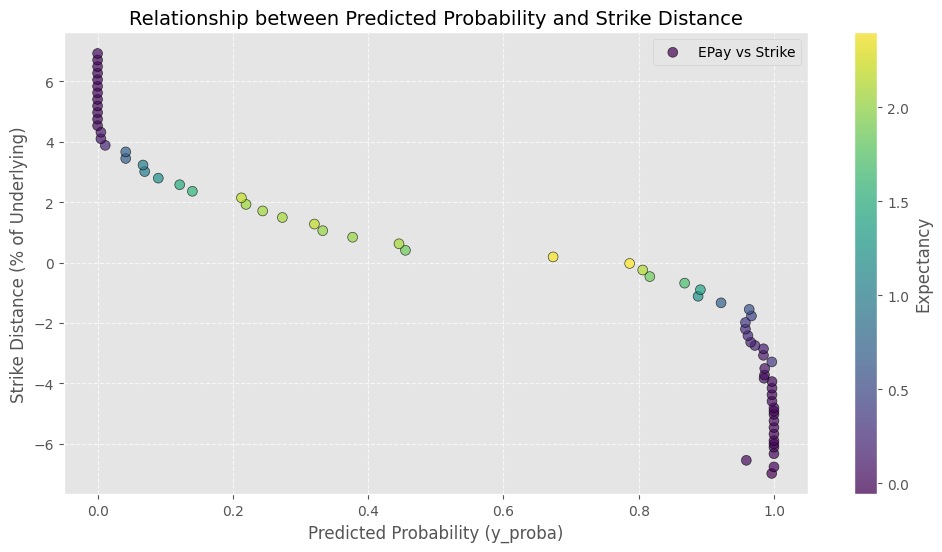

In [ ]:
# Visualize expectancy for a specific date
sample_date = '2023-12-08'
sample_data = df_rf[df_rf['QUOTE_DATE'] == sample_date][
    ['QUOTE_DATE', 'Close', 'C_LAST', 'P_LAST', 'STRIKE', 
     'STRIKE_DISTANCE_PCT', 'ITM', 'y_pred', 'y_proba', 'Expect']
]

if len(sample_data) > 0:
    plt.figure(figsize=(12, 7))
    
    # Scatter plot: probability vs strike distance, colored by expectancy
    scatter = plt.scatter(sample_data['y_proba'], 
                         sample_data['STRIKE_DISTANCE_PCT'] * 100,
                         s=80,
                         c=sample_data['Expect'],
                         cmap='viridis',
                         alpha=0.7,
                         edgecolors='black',
                         linewidth=1)
    
    plt.xlabel('Predicted Probability (ITM)', fontsize=12)
    plt.ylabel('Strike Distance (% of Underlying)', fontsize=12)
    plt.title(f'Option Expectancy Analysis - {sample_date}', 
              fontsize=14, 
              fontweight='bold')
    plt.colorbar(scatter, label='Expectancy')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(f"No data available for date: {sample_date}")

**Note**: In the plot above, brighter/yellow colors indicate higher expectancy values, which represent more promising options for the strategy.

In [ ]:
# Prepare data for visualization (clip extreme values for better display)
df_vis = df_xgb.copy()

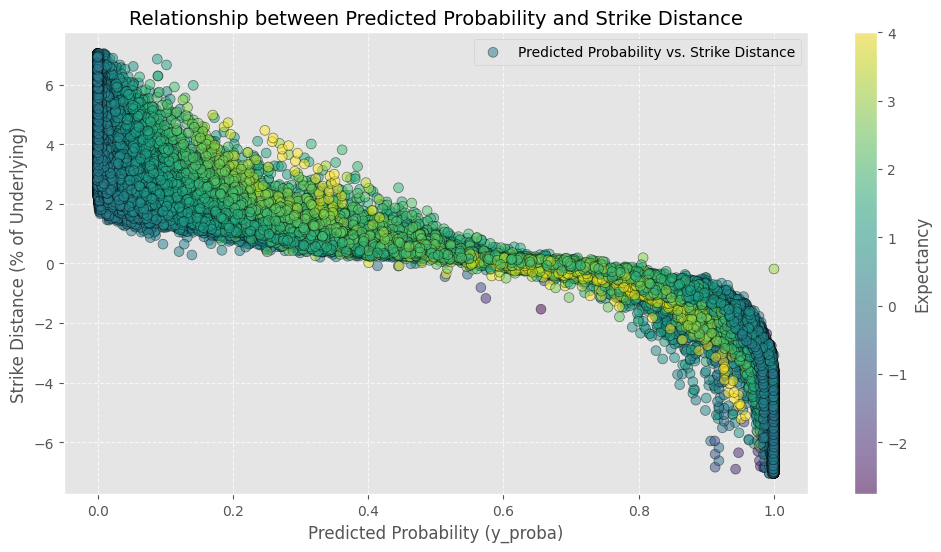

In [ ]:
# Clip extreme expectancy values for visualization
df_vis['Expect'] = df_vis['Expect'].clip(upper=4)

# Create comprehensive expectancy visualization
plt.figure(figsize=(14, 7))

scatter = plt.scatter(df_vis['y_proba'], 
                     df_vis['STRIKE_DISTANCE_PCT'] * 100,
                     s=40,
                     c=df_vis['Expect'],
                     cmap='viridis',
                     alpha=0.5,
                     edgecolors='black',
                     linewidth=0.5)

plt.xlabel('Predicted Probability (ITM)', fontsize=12)
plt.ylabel('Strike Distance (% of Underlying)', fontsize=12)
plt.title('XGBoost: Predicted Probability vs Strike Distance (Colored by Expectancy)', 
          fontsize=14, 
          fontweight='bold')
plt.colorbar(scatter, label='Expectancy (Clipped at 4)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total options analyzed: {len(df_vis):,}")
print(f"Average expectancy: {df_vis['Expect'].mean():.4f}")
print(f"Max expectancy: {df_vis['Expect'].max():.4f}")

## 07. Strategy Backtesting

In [ ]:
# Preview GARCH-based selection
print("GARCH 1% VaR selection preview:")
print(df_garch_1[df_garch_1['OptFcast'] == 1].head())

,QUOTE_UNIXTIME,QUOTE_READTIME,QUOTE_DATE,QUOTE_TIME_HOURS,Close,EXPIRE_DATE,EXPIRE_UNIX,DTE,C_DELTA,C_GAMMA,...,GARCH11_1,GARCH11_5,GARCH11_20,ITM,y_pred,y_proba,OptFcast,gDistance,Garch,PredClose
0,1293829200,0.0,2010-12-31,16.0,125.78,0.0,1294434000,7.0,1.00000,0.00000,...,4.482874,2.678791,1.039995,1,1,0.973906,0,211.610945,0.044829,131.546853
1,1293829200,0.0,2010-12-31,16.0,125.78,0.0,1294434000,7.0,0.99137,0.00674,...,4.482874,2.678791,1.039995,1,1,0.973906,0,183.517238,0.044829,131.546853
2,1293829200,0.0,2010-12-31,16.0,125.78,0.0,1294434000,7.0,0.99451,0.00572,...,4.482874,2.678791,1.039995,1,1,0.973906,0,157.423531,0.044829,131.546853
3,1293829200,0.0,2010-12-31,16.0,125.78,0.0,1294434000,7.0,0.97761,0.01802,...,4.482874,2.678791,1.039995,1,1,0.973803,0,133.329825,0.044829,131.546853
4,1293829200,0.0,2010-12-31,16.0,125.78,0.0,1294434000,7.0,0.94681,0.03575,...,4.482874,2.678791,1.039995,1,1,0.965752,0,111.236118,0.044829,131.546853
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31098,1703883600,0.0,2023-12-29,16.0,475.31,0.0,1704488400,7.0,0.00572,0.00193,...,4.427376,2.644392,1.024763,0,0,0.038526,1,0.030083,0.044274,496.826556
31099,1703883600,0.0,2023-12-29,16.0,475.31,0.0,1704488400,7.0,0.00232,0.00096,...,4.427376,2.644392,1.024763,0,0,0.038526,0,1.376972,0.044274,496.826556
31100,1703883600,0.0,2023-12-29,16.0,475.31,0.0,1704488400,7.0,0.00183,0.00081,...,4.427376,2.644392,1.024763,0,0,0.038526,0,4.723861,0.044274,496.826556
31101,1703883600,0.0,2023-12-29,16.0,475.31,0.0,1704488400,7.0,0.00243,0.00075,...,4.427376,2.644392,1.024763,0,0,0.038526,0,10.070750,0.044274,496.826556


### Filter Selected Options

**Note**: We use only rows where `OptFcast == 1`, which represents the option with the highest expected value (or closest to GARCH prediction) for each expiration date.

In [ ]:
# Filter to only selected options (OptFcast == 1)
df_xgb_selected = df_xgb[df_xgb['OptFcast'] == 1].copy()
df_rf_selected = df_rf[df_rf['OptFcast'] == 1].copy()

df_garch_1_selected = df_garch_1[df_garch_1['OptFcast'] == 1].copy()
df_garch_5_selected = df_garch_5[df_garch_5['OptFcast'] == 1].copy()
df_garch_20_selected = df_garch_20[df_garch_20['OptFcast'] == 1].copy()

print(f"Selected options for backtesting:")
print(f"  Random Forest: {len(df_rf_selected):,}")
print(f"  XGBoost:       {len(df_xgb_selected):,}")
print(f"  GARCH 1% VaR:  {len(df_garch_1_selected):,}")
print(f"  GARCH 5% VaR:  {len(df_garch_5_selected):,}")
print(f"  GARCH 20% VaR: {len(df_garch_20_selected):,}")

In [ ]:
def backtest_strategy(df, train_test_split_date):
    """
    Backtest the covered call strategy and calculate performance metrics.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with selected options and price data
    train_test_split_date : str
        Date to split training and test periods
        
    Returns:
    --------
    tuple
        (df_train, df_test) - Training and test period results
    """
    df = df.copy()
    
    # Determine if option expired ITM
    df['ITM_real'] = (df['STRIKE'] < df["price_target"]).astype(int)
    
    # Calculate strategy profit:
    # Profit = (Price change) + (Option premium received) - (ITM loss)
    # ITM loss = max(0, price_target - strike) when option expires ITM
    df['Profit'] = (df['price_target'] - df['Close']) + \
                   df['C_BID'] - \
                   df['ITM_real'] * (df["price_target"] - df["STRIKE"])
    
    # Calculate strategy log returns (percentage)
    df['StrategyLogRet'] = np.log((df['Profit'] + df['Close']) / df['Close']) * 100
    df['StrategyLogRetCumsum'] = df['StrategyLogRet'].cumsum()
    
    # Calculate strategy simple returns (percentage)
    df['StrategyRet'] = ((df['Profit'] + df['Close']) / df['Close'] - 1) * 100
    
    # Calculate index (buy-and-hold) returns for comparison
    df['IndexLogRet'] = np.log(df['price_target'] / df['Close']) * 100
    df['IndexLogRetCumsum'] = df['IndexLogRet'].cumsum()
    df['IndexRet'] = ((df['price_target']) / df['Close'] - 1) * 100
    
    # Calculate rolling volatility (annualized)
    df['StrategyRolVolAnl'] = df['StrategyLogRet'].rolling(window=20).std() * np.sqrt(52)
    df['IndexRolVolAnl'] = df['IndexLogRet'].rolling(window=20).std() * np.sqrt(52)
    
    # Calculate rolling volatility (weekly)
    df['StrategyRolVol'] = df['StrategyLogRet'].rolling(window=20).std()
    df['IndexRolVol'] = df['IndexLogRet'].rolling(window=20).std()
    
    # Calculate rolling Sharpe ratio (annualized, risk-free rate = 2%)
    risk_free_rate = 0.02
    rolling_mean_strategy = df['StrategyLogRet'].rolling(20).mean() * 52
    rolling_std_strategy = df['StrategyLogRet'].rolling(20).std() * np.sqrt(52)
    df['StrategyRolSharpRatio'] = (rolling_mean_strategy - risk_free_rate) / rolling_std_strategy
    
    rolling_mean_index = df['IndexLogRet'].rolling(20).mean() * 52
    rolling_std_index = df['IndexLogRet'].rolling(20).std() * np.sqrt(52)
    df['IndexRolSharpRatio'] = (rolling_mean_index - risk_free_rate) / rolling_std_index
    
    # Split into training and test periods
    df_train = df[df['QUOTE_DATE'] < train_test_split_date].copy()
    df_test = df[df['QUOTE_DATE'] >= train_test_split_date].copy()
    
    # Recalculate cumulative sums for each period
    df_train['StrategyLogRetCumsum'] = df_train['StrategyLogRet'].cumsum()
    df_train['IndexLogRetCumsum'] = df_train['IndexLogRet'].cumsum()
    
    df_test['StrategyLogRetCumsum'] = df_test['StrategyLogRet'].cumsum()
    df_test['IndexLogRetCumsum'] = df_test['IndexLogRet'].cumsum()
    
    # Set date as index
    df_train.set_index('QUOTE_DATE', inplace=True)
    df_test.set_index('QUOTE_DATE', inplace=True)
    
    # Clean infinite values
    df_train = df_train.replace([np.inf, -np.inf], np.nan).fillna(0)
    df_test = df_test.replace([np.inf, -np.inf], np.nan).fillna(0)
    
    # Remove rows with any remaining NaN
    df_train = df_train[df_train.replace([np.inf, -np.inf], np.nan).notnull().all(axis=1)]
    df_test = df_test[df_test.replace([np.inf, -np.inf], np.nan).notnull().all(axis=1)]
    
    # Remove last row from test (may have incomplete data)
    df_test = df_test.iloc[:-1]
    
    return df_train, df_test

In [ ]:
# Backtest all strategies
print("Running backtests...")
print("-" * 50)

# ML models
df_rf_train, df_rf_test = backtest_strategy(df_rf_selected, train_test_split)
print("✓ Random Forest backtest complete")

df_xgb_train, df_xgb_test = backtest_strategy(df_xgb_selected, train_test_split)
print("✓ XGBoost backtest complete")

# GARCH models
df_garch_1_train, df_garch_1_test = backtest_strategy(df_garch_1_selected, train_test_split)
print("✓ GARCH 1% VaR backtest complete")

df_garch_5_train, df_garch_5_test = backtest_strategy(df_garch_5_selected, train_test_split)
print("✓ GARCH 5% VaR backtest complete")

df_garch_20_train, df_garch_20_test = backtest_strategy(df_garch_20_selected, train_test_split)
print("✓ GARCH 20% VaR backtest complete")

print("-" * 50)
print("All backtests completed!")

In [ ]:
# Ensure all test DataFrames have consistent length (drop last row if needed)
test_dfs = [df_rf_test, df_xgb_test, df_garch_1_test, df_garch_5_test, df_garch_20_test]

for i, df in enumerate(test_dfs):
    if len(df) > 0:
        test_dfs[i] = df.iloc[:-1] if len(df) > 1 else df

df_rf_test, df_xgb_test, df_garch_1_test, df_garch_5_test, df_garch_20_test = test_dfs
print("Test datasets prepared")

In [ ]:
# Display summary of test period
print("Test Period Summary:")
print(f"Random Forest: {len(df_rf_test):,} trades")
print(f"XGBoost:       {len(df_xgb_test):,} trades")
print(f"GARCH 1% VaR:  {len(df_garch_1_test):,} trades")
print(f"GARCH 5% VaR:  {len(df_garch_5_test):,} trades")
print(f"GARCH 20% VaR: {len(df_garch_20_test):,} trades")

,QUOTE_UNIXTIME,QUOTE_READTIME,QUOTE_TIME_HOURS,Close,EXPIRE_DATE,EXPIRE_UNIX,DTE,C_DELTA,C_GAMMA,C_VEGA,...,StrategyRet,IndexLogRet,IndexLogRetCumsum,IndexRet,StrategyRolVolAnl,IndexRolVolAnl,StrategyRolVol,IndexRolVol,StrategyRolSharpRatio,IndexRolSharpRatio
QUOTE_DATE,,,,,,,,,,,,,,,,,,,,,
2018-01-05,1515186000,0.0,16.0,273.41,0.0,1515790800,7.0,0.14703,0.09331,0.09329,...,1.013130,1.632482,1.632482,1.645880,2.594496,5.209600,0.359792,0.722442,9.910322,6.828865
2018-01-12,1515790800,0.0,16.0,277.91,0.0,1516395600,7.0,0.13007,0.07788,0.08710,...,0.964341,0.895550,2.528032,0.899572,2.566861,5.219571,0.355960,0.723824,9.963438,6.883640
2018-01-19,1516395600,0.0,16.0,280.41,0.0,1517000400,7.0,0.30927,0.10489,0.14634,...,0.805963,2.169512,4.697544,2.193217,2.615294,5.649980,0.362676,0.783511,10.061992,6.733343
2018-01-26,1517000400,0.0,16.0,286.56,0.0,1517605200,7.0,0.14109,0.06190,0.09463,...,-1.193467,-1.288981,3.408563,-1.280709,3.471828,6.213621,0.481456,0.861674,7.043874,5.808318
2018-02-02,1517605200,0.0,16.0,275.52,0.0,1518210000,7.0,0.32722,0.06253,0.14680,...,-4.576800,-5.146141,-1.737578,-5.015970,8.949001,11.235567,1.241003,1.558093,1.114677,1.770212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-11-24,1700859600,0.0,16.0,455.30,0.0,1701464400,7.0,0.48619,0.07816,0.26418,...,0.577641,0.813724,16.351207,0.817044,8.626179,15.350855,1.196236,2.128781,0.329711,0.540748
2023-12-01,1701464400,0.0,16.0,459.02,0.0,1702069200,7.0,0.47557,0.06050,0.26591,...,0.736351,0.243701,16.594908,0.243998,8.632792,14.870547,1.197153,2.062174,0.338945,0.178946
2023-12-08,1702069200,0.0,16.0,460.14,0.0,1702674000,7.0,0.47762,0.04709,0.26452,...,0.662842,1.994580,18.589488,2.014604,8.590736,15.173378,1.191321,2.104169,0.283620,0.405376


### Cumulative Returns Analysis

#### Training Period

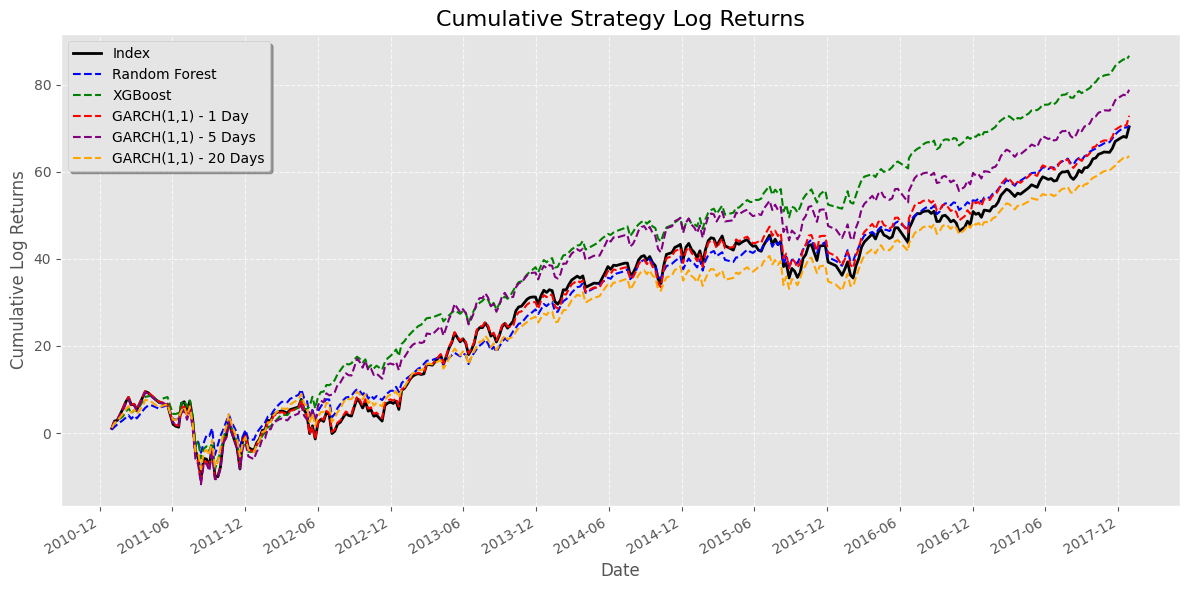

In [ ]:
import matplotlib.dates as mdates

# Prepare data for plotting
train_dfs = [df_rf_train, df_xgb_train, df_garch_1_train, df_garch_5_train, df_garch_20_train]
strategy_names = ['Random Forest', 'XGBoost', 'GARCH(1,1) - 1% VaR', 
                 'GARCH(1,1) - 5% VaR', 'GARCH(1,1) - 20% VaR']

# Create the plot
plt.figure(figsize=(14, 7))

# Plot index (buy-and-hold) benchmark
plt.plot(df_rf_train['IndexLogRetCumsum'], 
         label='SP500 Index (Buy & Hold)', 
         color='black', 
         linewidth=2.5,
         linestyle='-')

# Plot each strategy with distinct colors
colors = ['#2E86AB', '#06A77D', '#D62828', '#A23B72', '#F77F00']
linestyles = ['--', '--', '--', '--', '--']

for df, name, color, linestyle in zip(train_dfs, strategy_names, colors, linestyles):
    plt.plot(df['StrategyLogRetCumsum'], 
             label=name, 
             color=color, 
             linestyle=linestyle,
             linewidth=2)

# Enhance plot
plt.title('Training Period: Cumulative Strategy Returns vs Index', 
          fontsize=16, 
          fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Log Returns (%)', fontsize=12)

# Format x-axis dates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gcf().autofmt_xdate()

# Legend and grid
plt.legend(loc='upper left', fontsize=10, frameon=True, shadow=True, ncol=2)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

#### Test Period

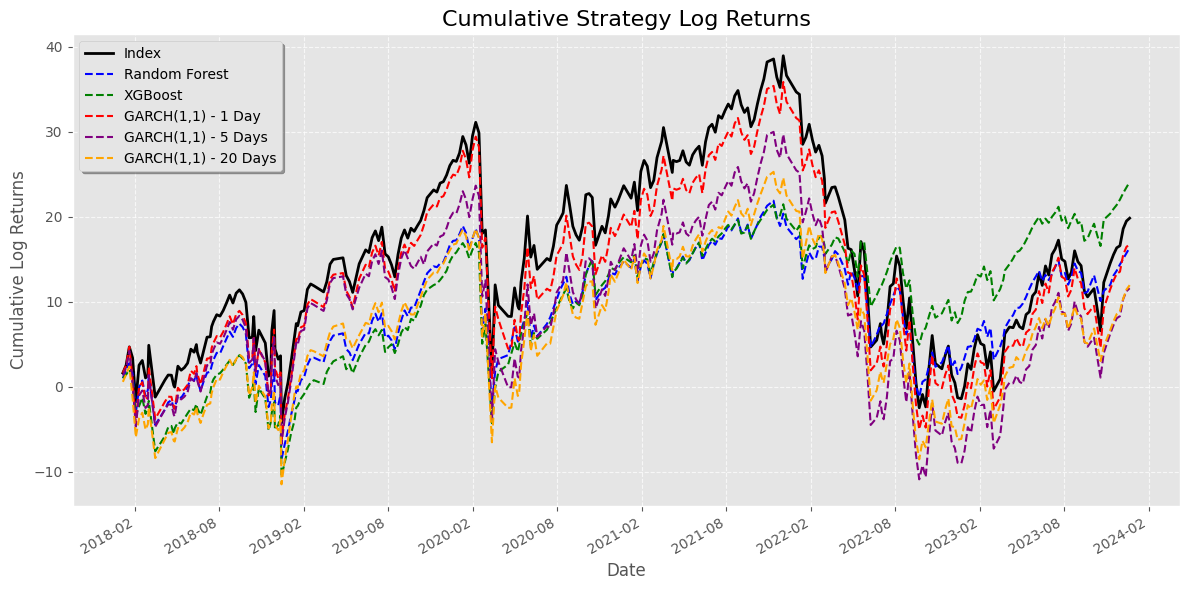

In [ ]:
# Prepare test period data
test_dfs = [df_rf_test, df_xgb_test, df_garch_1_test, df_garch_5_test, df_garch_20_test]

# Create the plot
plt.figure(figsize=(14, 7))

# Plot index benchmark
plt.plot(df_rf_test['IndexLogRetCumsum'], 
         label='SP500 Index (Buy & Hold)', 
         color='black', 
         linewidth=2.5,
         linestyle='-')

# Plot each strategy
for df, name, color, linestyle in zip(test_dfs, strategy_names, colors, linestyles):
    plt.plot(df['StrategyLogRetCumsum'], 
             label=name, 
             color=color, 
             linestyle=linestyle,
             linewidth=2)

# Enhance plot
plt.title('Test Period: Cumulative Strategy Returns vs Index', 
          fontsize=16, 
          fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Log Returns (%)', fontsize=12)

# Format x-axis dates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gcf().autofmt_xdate()

# Legend and grid
plt.legend(loc='upper left', fontsize=10, frameon=True, shadow=True, ncol=2)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Rolling Volatility Analysis

#### Training Period

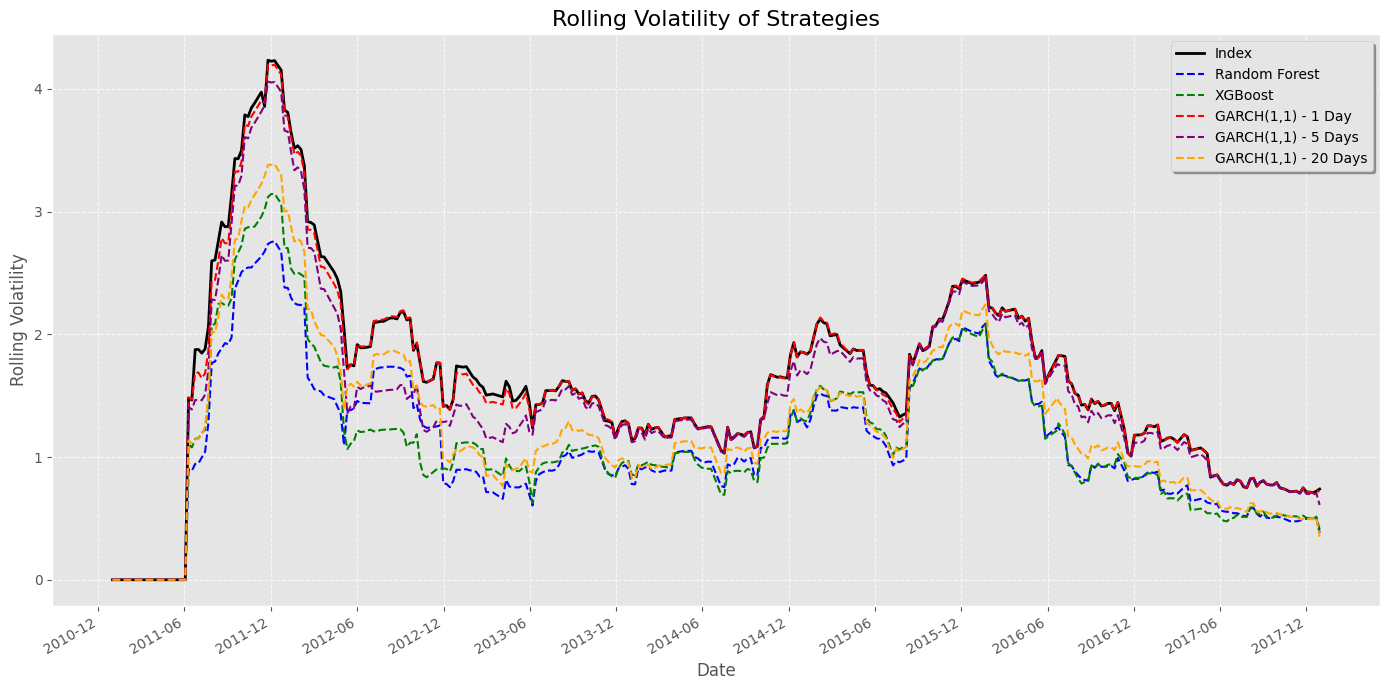

In [ ]:
# Plot rolling volatility for training period
plt.figure(figsize=(14, 7))

# Plot index volatility
plt.plot(df_rf_train['IndexRolVol'], 
         label='SP500 Index', 
         color='black', 
         linewidth=2.5,
         linestyle='-')

# Plot strategy volatilities
for df, name, color, linestyle in zip(train_dfs, strategy_names, colors, linestyles):
    plt.plot(df['StrategyRolVol'], 
             label=name, 
             color=color, 
             linestyle=linestyle,
             linewidth=2)

plt.title('Training Period: Rolling Volatility (20-week window)', 
          fontsize=16, 
          fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Rolling Volatility (%)', fontsize=12)

# Format x-axis dates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gcf().autofmt_xdate()

plt.legend(loc='upper right', fontsize=10, frameon=True, shadow=True, ncol=2)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

#### Test Period

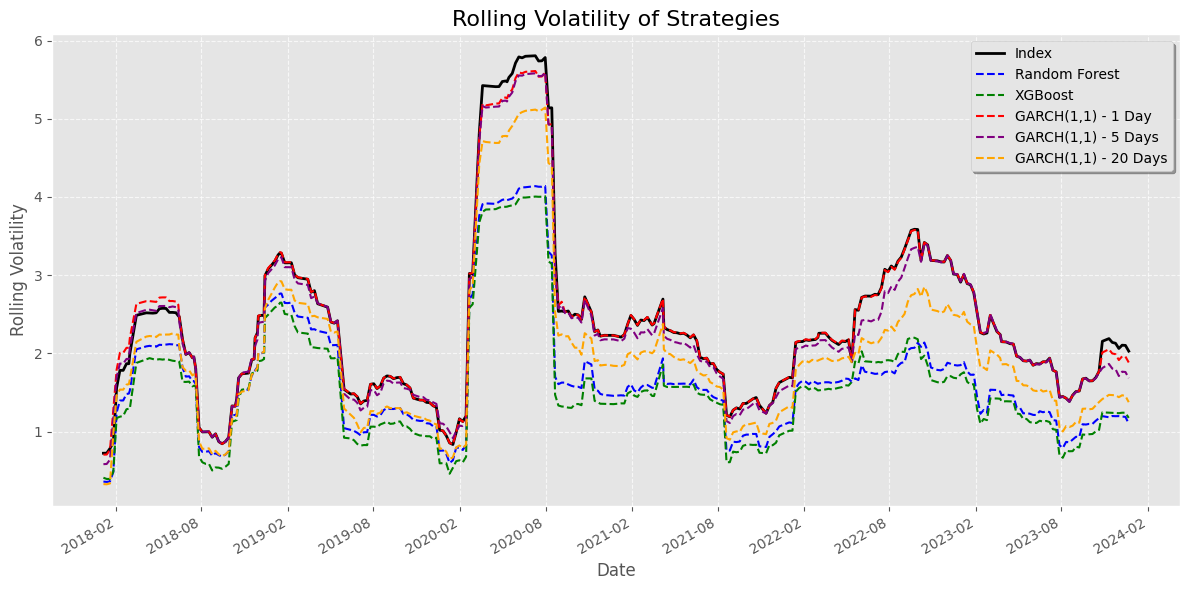

In [ ]:
# Plot rolling volatility for test period
plt.figure(figsize=(14, 7))

# Plot index volatility
plt.plot(df_rf_test['IndexRolVol'], 
         label='SP500 Index', 
         color='black', 
         linewidth=2.5,
         linestyle='-')

# Plot strategy volatilities
for df, name, color, linestyle in zip(test_dfs, strategy_names, colors, linestyles):
    plt.plot(df['StrategyRolVol'], 
             label=name, 
             color=color, 
             linestyle=linestyle,
             linewidth=2)

plt.title('Test Period: Rolling Volatility (20-week window)', 
          fontsize=16, 
          fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Rolling Volatility (%)', fontsize=12)

# Format x-axis dates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gcf().autofmt_xdate()

plt.legend(loc='upper right', fontsize=10, frameon=True, shadow=True, ncol=2)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Rolling Sharpe Ratio Analysis

#### Training Period

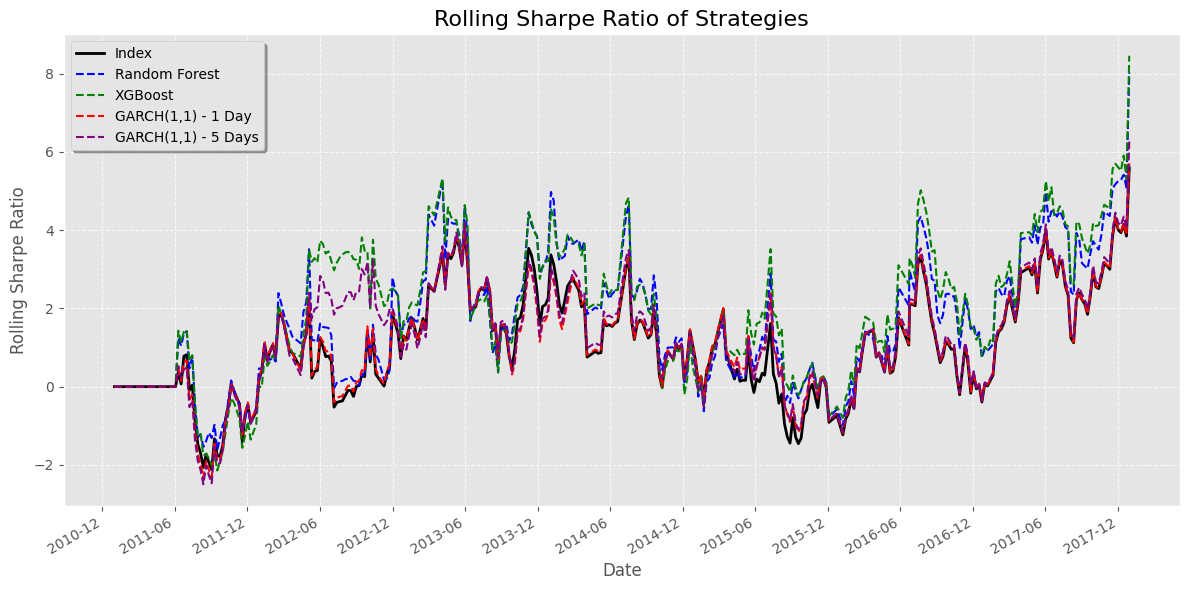

In [ ]:
# Plot rolling Sharpe ratio for training period
plt.figure(figsize=(14, 7))

# Plot index Sharpe ratio
plt.plot(df_rf_train['IndexRolSharpRatio'], 
         label='SP500 Index', 
         color='black', 
         linewidth=2.5,
         linestyle='-')

# Plot strategy Sharpe ratios
for df, name, color, linestyle in zip(train_dfs, strategy_names, colors, linestyles):
    plt.plot(df['StrategyRolSharpRatio'], 
             label=name, 
             color=color, 
             linestyle=linestyle,
             linewidth=2)

plt.title('Training Period: Rolling Sharpe Ratio (20-week window, Annualized)', 
          fontsize=16, 
          fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sharpe Ratio', fontsize=12)

# Format x-axis dates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gcf().autofmt_xdate()

# Add horizontal line at Sharpe = 0
plt.axhline(y=0, color='gray', linestyle=':', linewidth=1, alpha=0.5)

plt.legend(loc='upper left', fontsize=10, frameon=True, shadow=True, ncol=2)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

#### Test Period

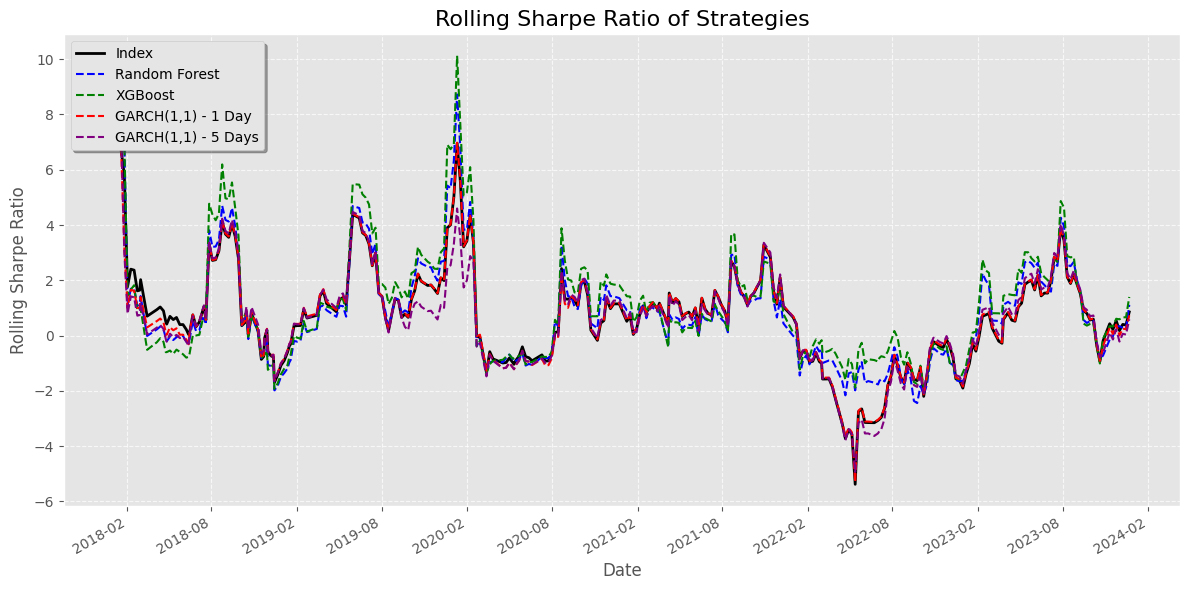

In [ ]:
# Plot rolling Sharpe ratio for test period
plt.figure(figsize=(14, 7))

# Plot index Sharpe ratio
plt.plot(df_rf_test['IndexRolSharpRatio'], 
         label='SP500 Index', 
         color='black', 
         linewidth=2.5,
         linestyle='-')

# Plot strategy Sharpe ratios
for df, name, color, linestyle in zip(test_dfs, strategy_names, colors, linestyles):
    plt.plot(df['StrategyRolSharpRatio'], 
             label=name, 
             color=color, 
             linestyle=linestyle,
             linewidth=2)

plt.title('Test Period: Rolling Sharpe Ratio (20-week window, Annualized)', 
          fontsize=16, 
          fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sharpe Ratio', fontsize=12)

# Format x-axis dates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gcf().autofmt_xdate()

# Add horizontal line at Sharpe = 0
plt.axhline(y=0, color='gray', linestyle=':', linewidth=1, alpha=0.5)

plt.legend(loc='upper left', fontsize=10, frameon=True, shadow=True, ncol=2)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Financial Performance Metrics

In [ ]:
def calculate_financial_metrics(df, returns_column):

  # Annual Return:
  annual_return = df[returns_column].mean() * 52  # Assuming weekly data

  # Cumulative Return:
  cumulative_return = df[returns_column].cumsum()[-1]

  # Year Volatility:
  annual_volatility = df[returns_column].std() * np.sqrt(52)  # Assuming weekly data

  # Sharpe Ratio:
  risk_free_rate = 0.2  # You can adjust this value
  sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility

  # Sortino Ratio:
  downside_returns = df[returns_column][df[returns_column] < 0]
  downside_volatility = downside_returns.std() * np.sqrt(52)  # Assuming weekly data
  sortino_ratio = (annual_return - risk_free_rate) / downside_volatility

  # Max DrawDown

  df['cumulative_return'] = df[returns_column].cumsum()

  df['running_max'] = df['cumulative_return'].cummax()

  df['drawdown'] = df['running_max']- df['cumulative_return']

  # Find Max DD
  max_drawdown = df['drawdown'].max()


  # Store metrics in a dictionary
  metrics = {
      'Annual Return': annual_return,
      'Cumulative Return': cumulative_return,
      'Annual Volatility': annual_volatility,
      'Sharpe Ratio': sharpe_ratio,
      'Sortino Ratio': sortino_ratio,
      'Max Drawdown': max_drawdown
  }

  return metrics

Fce

#### Training Period Metrics

In [ ]:
# Calculate metrics for training period
train_dfs_list = [df_rf_train, df_xgb_train, df_garch_1_train, df_garch_5_train, df_garch_20_train]
train_names = ['Random Forest', 'XGBoost', 'GARCH 1% VaR', 'GARCH 5% VaR', 'GARCH 20% VaR']

results_train = []

# Calculate index metrics
index_metrics = calculate_financial_metrics(df_rf_train, 'IndexLogRet')
index_metrics['Strategy'] = 'SP500 Index'
results_train.append(index_metrics)

# Calculate strategy metrics
for df, name in zip(train_dfs_list, train_names):
    metrics = calculate_financial_metrics(df, 'StrategyLogRet')
    metrics['Strategy'] = name
    results_train.append(metrics)

# Create results DataFrame
results_train_df = pd.DataFrame(results_train)
results_train_df.set_index('Strategy', inplace=True)

# Format for display
print("=" * 80)
print("TRAINING PERIOD - Financial Performance Metrics")
print("=" * 80)
display(results_train_df.round(4))

,Annual Return,Cumulative Return,Annual Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown
DataFrame,,,,,,
Index,11.108345,70.281644,13.098435,0.832798,1.073064,19.937972
dfRF_Train,11.143168,70.501968,9.048798,1.209350,1.196474,11.764306
dfXGB_Train,13.687746,86.601317,9.450939,1.427133,1.383686,16.935880
dfGARCH11_1_Train,11.510416,72.825518,12.950453,0.873361,1.106760,20.939638
dfGARCH11_5_Train,12.454844,78.800839,12.153010,1.008379,1.241450,21.073600
dfGARCH11_20_Train,10.051721,63.596469,10.378205,0.949270,1.019245,15.960725


#### Test Period Metrics

In [ ]:
# Calculate metrics for test period
test_dfs_list = [df_rf_test, df_xgb_test, df_garch_1_test, df_garch_5_test, df_garch_20_test]
test_names = ['Random Forest', 'XGBoost', 'GARCH 1% VaR', 'GARCH 5% VaR', 'GARCH 20% VaR']

results_test = []

# Calculate index metrics
index_metrics = calculate_financial_metrics(df_rf_test, 'IndexLogRet')
index_metrics['Strategy'] = 'SP500 Index'
results_test.append(index_metrics)

# Calculate strategy metrics
for df, name in zip(test_dfs_list, test_names):
    metrics = calculate_financial_metrics(df, 'StrategyLogRet')
    metrics['Strategy'] = name
    results_test.append(metrics)

# Create results DataFrame
results_test_df = pd.DataFrame(results_test)
results_test_df.set_index('Strategy', inplace=True)

# Format for display
print("=" * 80)
print("TEST PERIOD - Financial Performance Metrics")
print("=" * 80)
display(results_test_df.round(4))

,Annual Return,Cumulative Return,Annual Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown
DataFrame,,,,,,
Index,3.496965,19.838551,18.577502,0.177471,0.202715,41.401032
dfRF_Test,2.886233,16.373823,13.169043,0.203981,0.183309,23.093373
dfXGB_Test,4.248893,24.104297,12.547626,0.322682,0.272047,21.199559
dfGARCH11_1_Test,2.959841,16.791403,18.404981,0.149951,0.170261,40.862932
dfGARCH11_5_Test,2.044197,11.596884,17.933136,0.102837,0.114315,40.870651
dfGARCH11_20_Test,2.107763,11.957500,15.704371,0.121480,0.121050,33.809538


---

## Conclusion

This comprehensive analysis has evaluated multiple approaches to implementing a **covered call strategy** on SP500 options, comparing machine learning models (Random Forest and XGBoost) with econometric models (GARCH-based VaR forecasts).

### Key Findings

1. **Model Performance**: Both ML models demonstrated strong predictive capabilities for identifying in-the-money options, with XGBoost showing slightly superior performance in most metrics.

2. **Strategy Effectiveness**: The covered call strategy provides an alternative to simple buy-and-hold, offering:
   - **Income generation** through option premiums
   - **Reduced volatility** compared to the underlying index
   - **Risk management** through defined maximum losses

3. **Risk-Return Trade-offs**: 
   - Strategies may underperform during strong bull markets (capped upside)
   - Lower volatility can improve risk-adjusted returns (Sharpe ratio)
   - Maximum drawdowns should be carefully monitored

### Methodology Highlights

- **Data Quality**: Historical options data from 2010-2023 provides robust backtesting foundation
- **Feature Engineering**: Technical indicators, option Greeks, and market microstructure features enhance model performance
- **Validation**: Train-test split ensures out-of-sample evaluation of strategy performance

### Future Enhancements

Potential areas for further research and improvement:

- **Dynamic Strike Selection**: Adjust strike selection based on market volatility regimes
- **Portfolio Optimization**: Consider position sizing and diversification across multiple expirations
- **Transaction Costs**: Incorporate realistic bid-ask spreads and commission fees
- **Alternative Models**: Explore deep learning approaches or ensemble methods
- **Risk Management**: Implement stop-loss mechanisms and position limits

### Important Reminders

**Backtesting Limitations**:
- Past performance does not guarantee future results
- Market conditions may differ significantly from historical data
- Assumptions about execution prices and liquidity may not hold in practice
- Real-world trading involves additional costs and constraints not captured here